# Executive Summary — Telco Customer Churn Analysis

---

## Business Problem

Customer churn is a major challenge in the telecom industry because retaining existing customers is significantly more cost-effective than acquiring new ones. This analysis explores customer behaviour patterns to identify factors associated with churn, detect high-risk customer segments, and evaluate whether predictive modelling can support proactive retention strategies.

The analysis uses a dataset of 7,043 telecom customers containing demographic information, service subscriptions, billing behaviour, and contract details.

---

## Key Findings

### Customer Churn Patterns

- The overall churn rate is approximately **26%**, meaning roughly 1 in 4 customers discontinued their service.
- Customers on **month-to-month contracts** demonstrated substantially higher churn rates compared to customers on annual or two-year contracts.
- Customers within their **first 12 months** showed the highest churn risk, while churn rates declined significantly among long-tenure customers.
- Customers using **Fiber Optic internet**, **electronic check payment methods**, and customers without additional support services showed comparatively higher churn rates.
- A combination of **short tenure + month-to-month contract + Fiber Optic service** emerged as one of the highest-risk customer segments identified during the analysis.

---

## Key Drivers of Churn

SHAP explainability analysis identified the following features as the most influential contributors to churn prediction:

| Driver | Business Interpretation |
|---|---|
| **Contract Type** | Short-term contracts are associated with lower customer retention and weaker loyalty. |
| **Tenure** | Newer customers are more likely to leave before long-term engagement is established. |
| **Monthly Charges** | Higher monthly costs may increase price sensitivity and churn likelihood. |
| **Fiber Optic + Month-to-Month Combination** | Certain service-plan combinations are associated with elevated churn risk. |
| **Electronic Check Payment** | Manual payment behaviour is associated with comparatively higher churn rates. |
| **Lack of Support Services** | Customers without services such as OnlineSecurity or TechSupport showed higher churn rates. |

---

## Predictive Modelling Results

Three machine learning models were evaluated:

- Logistic Regression
- Random Forest
- XGBoost

Among the evaluated models, **XGBoost** delivered the strongest balance between recall and overall predictive performance after threshold optimisation.

### Final Model Performance

| Metric | Value |
|---|---|
| ROC-AUC | 0.843 |
| Recall (Churn Class) | 85.0% |
| Precision (Churn Class) | 47.8% |

Using a recall-focused decision threshold, the model successfully identified the majority of customers likely to churn, making it potentially useful for targeted retention campaigns where intervention costs are lower than expected customer revenue loss.

---

## Business Recommendations

### 1. Promote Long-Term Contract Adoption

Customers on month-to-month plans consistently demonstrated higher churn rates. Targeted incentives encouraging migration to annual contracts may help improve retention.

**Example strategy:**  
> “Upgrade to a 1-year plan and receive discounted pricing for the first 3 months.”

---

### 2. Strengthen Early-Customer Retention

Customers in their first year represent the highest-risk group. Proactive engagement during the onboarding phase may reduce early churn risk.

Recommended actions:

- Early retention outreach
- Service onboarding assistance
- Usage engagement campaigns

---

### 3. Encourage Auto-Pay Adoption

Customers using electronic check payment methods showed higher churn rates compared to customers using automated payment methods.

Potential interventions:

- Auto-pay discounts
- Billing convenience campaigns
- Simplified payment migration process

---

### 4. Expand Support-Service Adoption

Customers without OnlineSecurity or TechSupport services demonstrated comparatively higher churn rates.

Potential strategy:

- Bundle support services during onboarding
- Offer limited-duration free trials
- Promote service value through targeted communication

---

### 5. Monitor High-Risk Customer Segments

Specific combinations of customer attributes — including short tenure, month-to-month contracts, and higher monthly charges — were associated with elevated churn probability and may benefit from priority retention monitoring.

---

## Operational Recommendation

The model can be used as part of a recurring customer-retention workflow:

- Perform monthly churn-risk scoring for active customers
- Prioritise high-risk customer segments for retention outreach
- Use SHAP explainability outputs to identify customer-level churn drivers
- Periodically retrain the model as customer behaviour patterns evolve

---

## Analysis Workflow

```text
Data Cleaning & Exploratory Analysis
→ Customer Segmentation & Churn Analysis
→ Feature Engineering
→ Predictive Modelling
→ Threshold Optimisation
→ SHAP Explainability Analysis
→ Business Recommendations
```

---

## Limitations

- The dataset represents a static snapshot of customer behaviour and does not capture behavioural changes over time.
- External influences such as competitor pricing, regional factors, customer service quality, and marketing interactions were not available in the dataset.
- Model performance and threshold selection may vary depending on business objectives and retention campaign cost assumptions.
- The analysis identifies predictive associations with churn and should not be interpreted as establishing direct causality.

---

*Analysis by: SRISHTI*  
*Dataset: IBM Telco Customer Churn Dataset*  
*Best-performing evaluated model: XGBoost*

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

## DATA UNDERSTANDING

# What we have Analyzed : 

- `Total charges` is in str, so first we'll convert it into numeric.
- There are customers with `tenure = 0` (just joined), their `TotalCharges` has been set equal to their `MonthlyCharges`, which is a reasonable assumption for a customer in their first billing cycle. These 11 rows are edge cases and their impact on analysis is negligible, but they are retained to preserve the full dataset.
- 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines' all these columns are categorical, they have value 'Yes', 'No', 'No internet service' or 'No phone service'. 'No internet service' or 'No phone service' also mean the same thing that is the customer doesn't have the feature.
- There is no null value.
- There are no duplicates.
- All ther binary categories are `Yes`/`No`, but `SeniorCitizen`is `0`/`1`. This inconsistency can cause problem during bi-variate analysis.
- `customerID` is a non-informative column, so it's better to drop it now.

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
## list of Columns to Clean
cols_to_fix = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service' : 'No'})

In [10]:
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service':'No'})

In [11]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0:'No', 1:'Yes'})

In [12]:
df.drop(columns=['customerID'], inplace=True)

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [14]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [15]:
df[df['TotalCharges'].isnull()][['MonthlyCharges', 'tenure', 'TotalCharges']]

,MonthlyCharges,tenure,TotalCharges
488,52.55,0,NaN
753,20.25,0,NaN
936,80.85,0,NaN
1082,25.75,0,NaN
1340,56.05,0,NaN
3331,19.85,0,NaN
3826,25.35,0,NaN
4380,20.00,0,NaN
5218,19.70,0,NaN
6670,73.35,0,NaN


In [16]:
df.loc[df['TotalCharges'].isnull(), 'TotalCharges'] = df.loc[df['TotalCharges'].isnull(), 'MonthlyCharges']

In [17]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [18]:
df[df['tenure'] == 0][['tenure', 'MonthlyCharges', 'TotalCharges']].head(11)

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,52.55
753,0,20.25,20.25
936,0,80.85,80.85
1082,0,25.75,25.75
1340,0,56.05,56.05
3331,0,19.85,19.85
3826,0,25.35,25.35
4380,0,20.00,20.00
5218,0,19.70,19.70
6670,0,73.35,73.35


In [19]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.798992
std,24.559481,30.090047,2266.730170
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


## UNIVARIATE ANALYSIS

## Categorical Columns
- The dataset has ~73% `No` and ~27% `Yes` churn. While not extreme, this imbalance means:
    - A naive model that always predicts `No` achieves 73% accuracy — misleadingly high.
    - We must NOT use accuracy alone as the evaluation metric during modeling.
    - Recommended metrics: F1-score (minority `Yes` class), AUC-ROC, Precision-Recall AUC.
- There are almost same percentage of males and females.
- There are approx 84% people who are not `SeniorCitizen`.
- There are approx 48% of people who have `Partner`.
- There are approx 70% people who do not have any `Dependents`.
- `Electronic Check` is the most used `Payment Method` followed by `Mailed check` then `Bank Transfer` and least used is `Credit Card`.
- Most popular `Contract` is `month-to-month` followed by `Two Year` and least popular is `One Year`.
- 90% people are using `Phone Services`.
- Approx 44% people are using `Fibre Optics`, 34% people are using `DSL`, remaining people don't have any `Internet Services`.
- Only 42% people have taken `Multiple Lines`.
- 28% people have taken `Online Security`.
- 34% people have taken `Online Backup`.
- 34% people have taken `Device Protection`.
- 29% people have taken `Tech Support`.
- 38% people have taken `Streaming TV`.
- 39% people have taken `Streaming Movies`.
- 59% people are using `Paperless Billing`.

In [20]:
plt.rcParams.update({
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : False,
    'axes.grid'         : True,
    'axes.grid.axis'    : 'y',
    'grid.alpha'        : 0.3,
    'grid.linestyle'    : '--',
    'font.size'         : 11,
})

PALETTE = '#378ADD'   

cat_cols = [
    'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
    'Contract', 'PaymentMethod'
]

num_cols_plot = ['tenure', 'MonthlyCharges', 'TotalCharges']

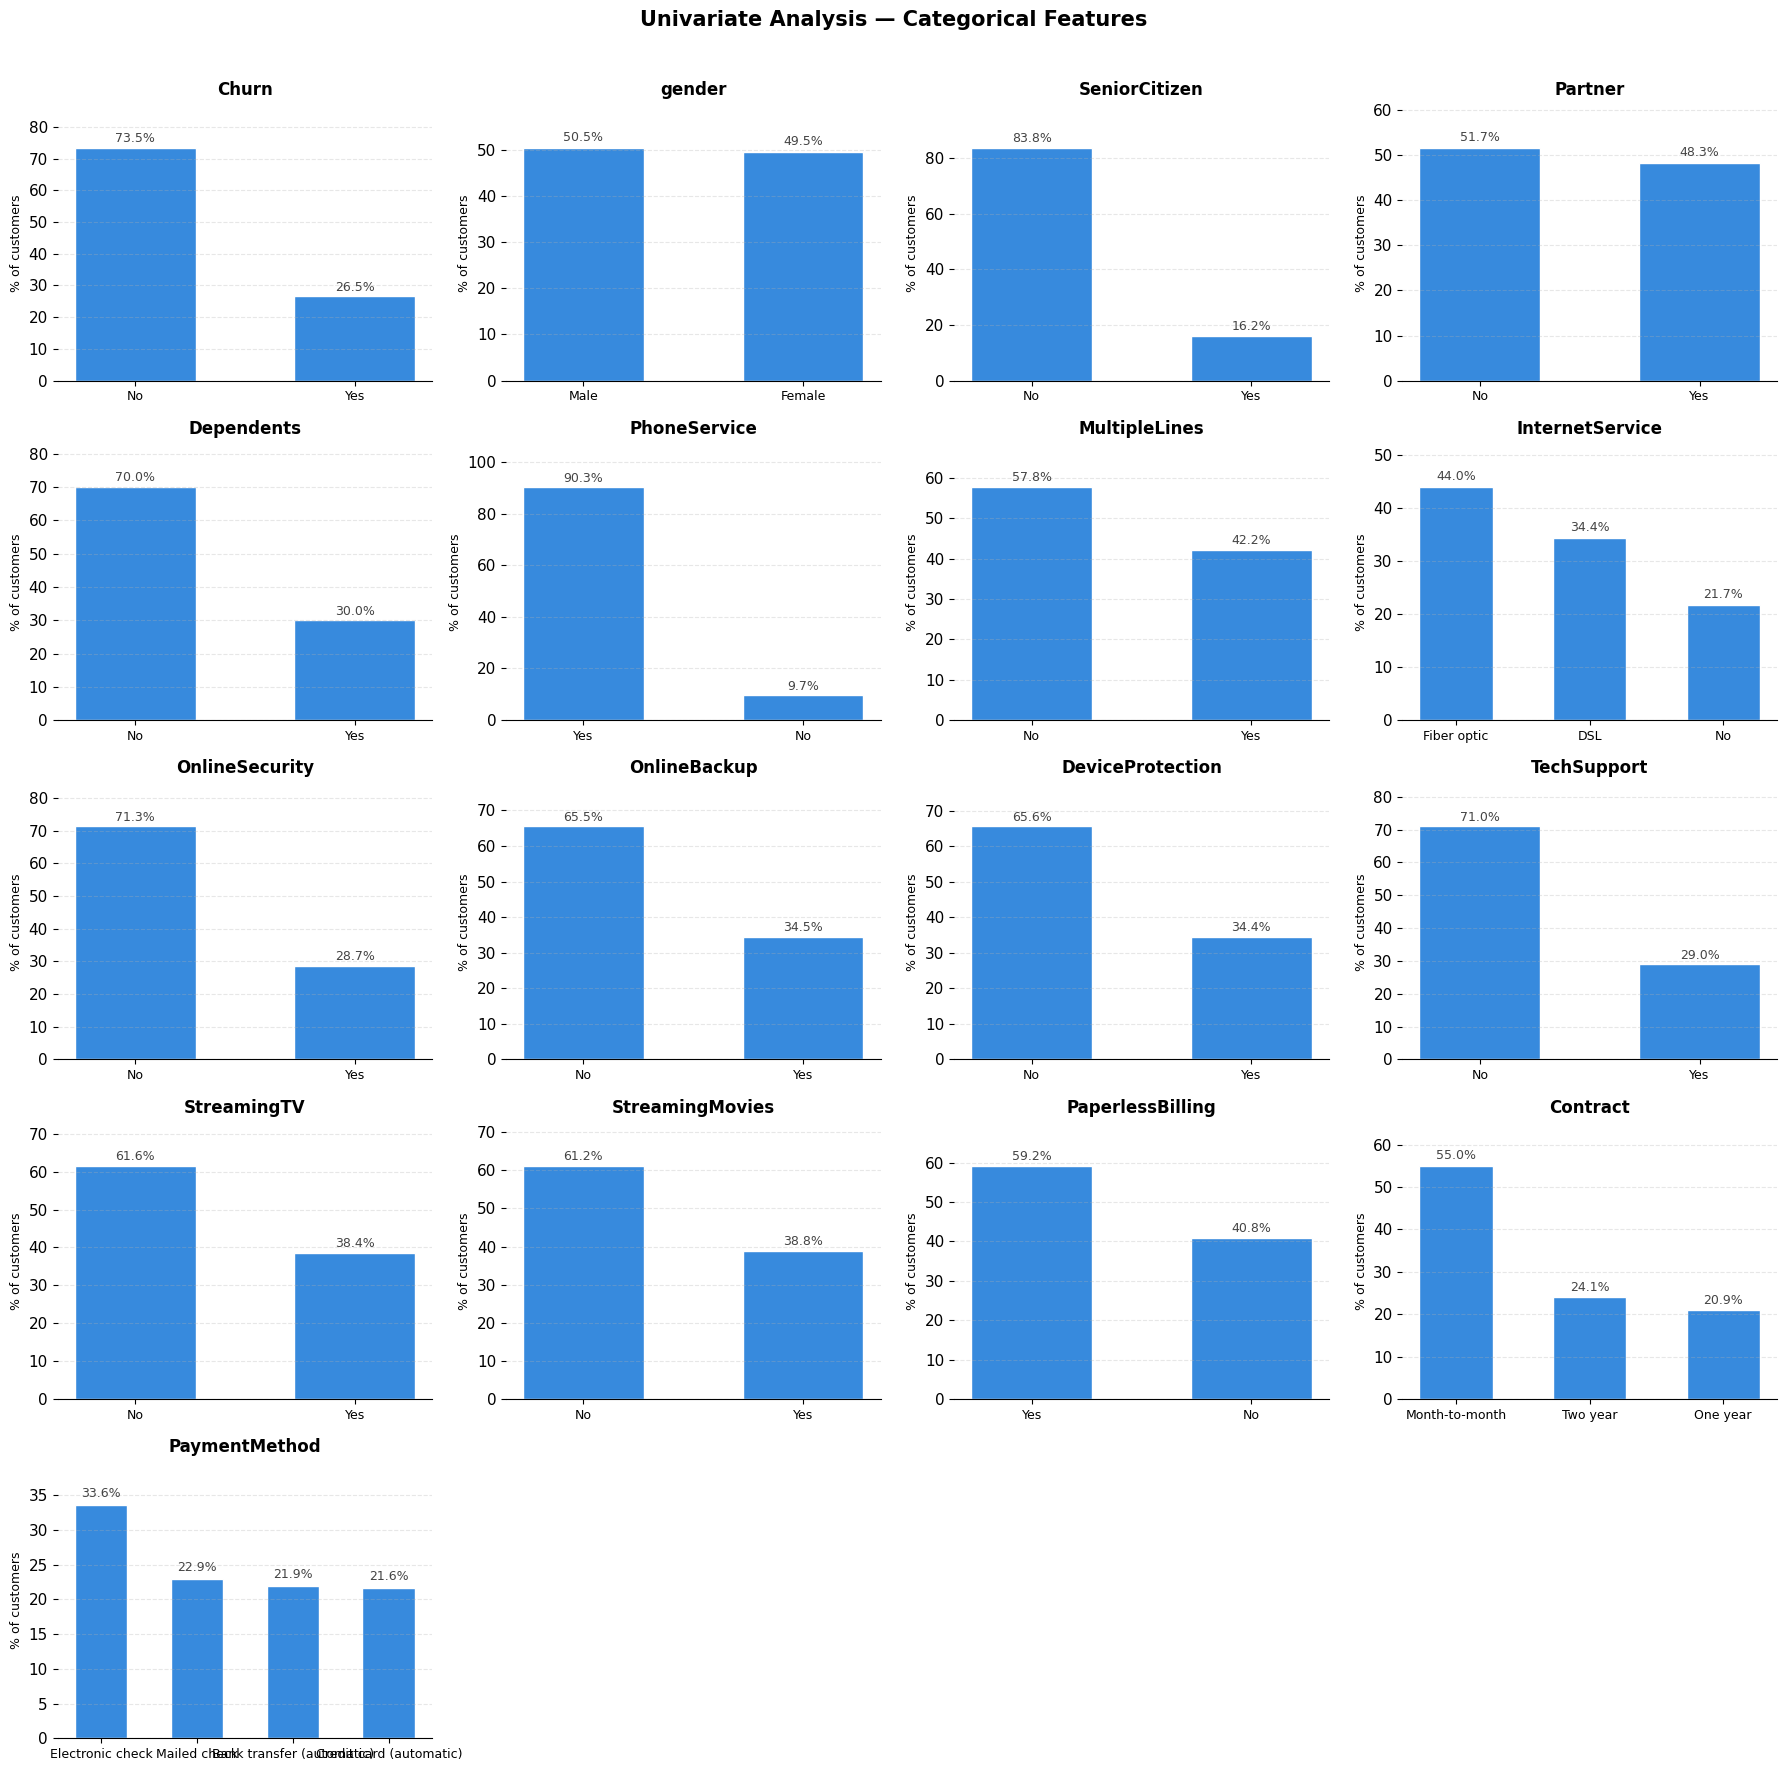

In [21]:
n_cols = 4
n_rows = -(-len(cat_cols) // n_cols)   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    pct = df[col].value_counts(normalize=True) * 100
    bars = ax.bar(pct.index.astype(str), pct.values, color=PALETTE, edgecolor='white', width=0.55)
    
    # annotate each bar with its percentage
    for bar, val in zip(bars, pct.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9, color='#444'
        )
    
    ax.set_title(col.replace('_', ' '), fontsize=12, fontweight='bold', pad=8)
    ax.set_ylabel('% of customers', fontsize=9)
    ax.set_ylim(0, pct.values.max() * 1.18)
    ax.tick_params(axis='x', labelsize=9)

# hide unused axes
for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.suptitle('Univariate Analysis — Categorical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('univariate_categorical.png', dpi=600, bbox_inches='tight')
plt.show()

## Numerical Column

- `Tenure` is bit right-skewed, `Monthly Charges` is bit left-skewed, and `Total Charges` is highly right-skewed.
- Most number of people have `Tenure` either between 65 to 70 or less than 10.
- `Monthly Charges` is weirdly distributed, most people have monthly charges between 20-30 followed by 70-100.
- Most of the people have `Total Charges` under 1000.

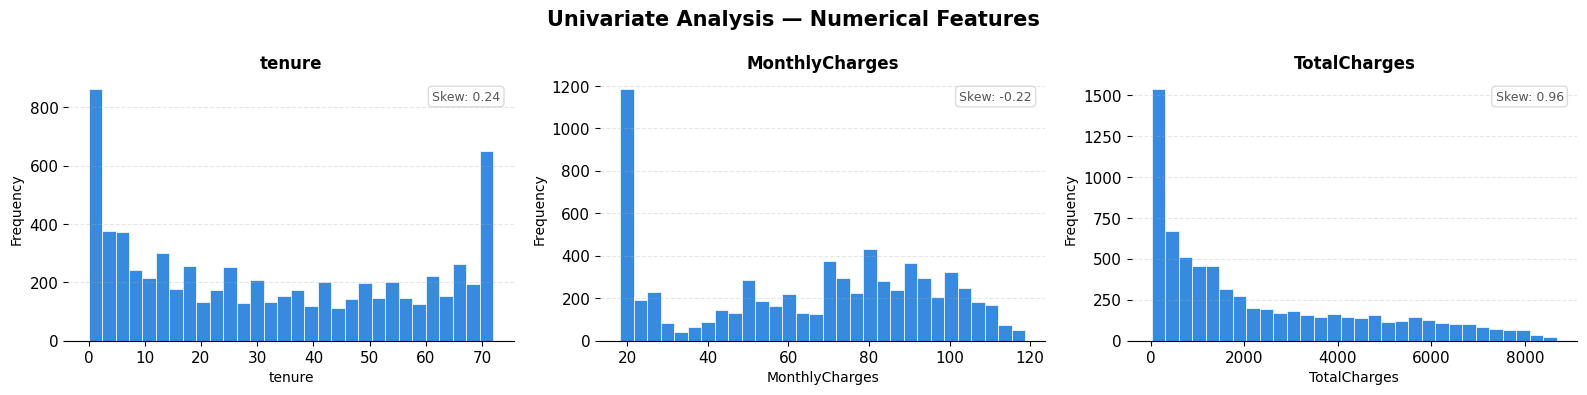

In [22]:
# ── Numerical grid ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, num_cols_plot):
    ax.hist(df[col], bins=30, color=PALETTE, edgecolor='white', linewidth=0.5)
    ax.set_title(col.replace('_', ' '), fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    
    # skewness annotation
    skew_val = df[col].skew()
    ax.text(0.97, 0.95, f'Skew: {skew_val:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color='#555',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='#ccc'))

plt.suptitle('Univariate Analysis — Numerical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('univariate_numerical.png', dpi=600, bbox_inches='tight')
plt.show()

# reset rcParams so rest of notebook isn't affected
plt.rcParams.update(plt.rcParamsDefault)

## Additional Changes
- For bivariate analysis, we would require a numerical version of `Churn`.

In [23]:
df['Churn_Binary'] = df['Churn'].map({'Yes':1, 'No':0})

In [24]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary
0,Female,No,Yes,No,1,No,No,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,No,No,No,45,No,No,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## BI-VARIATE ANALYSIS

In [25]:
from scipy import stats

In [26]:
churn_colors = {'No': '#378ADD', 'Yes': '#D85A30'}

In [27]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Binary'],
      dtype='str')

## Categorical VS Churn
- Dashed Gray line is the overall Churn Rate.
  - Bars above the gray line shows categories with `higher-than-average Churn`
  - Bars below the gray line shows categories with `lower-than-average churn`.
# Insights from the Bar Charts
1. `Contract Type` is one of the strongest churn signals
   - Month-to-month customers churn the most by far.
   - One-year customers churn much less.
   - Two-year customers churn the least.

This usually means customers with longer contracts are more stable and less likely to leave.

2. `Payment Method` matters a lot
   - Electronic check users have the highest churn.
   - Automatic payments like bank transfer and credit card show much lower churn.
   - Mailed check is also lower than electronic check.

This suggests customers using electronic check may be less “locked in” or less satisfied.

3. `Fiber optic` customers churn more
   - Fiber optic has much higher churn than DSL and No internet service.

So `internet service` type is a strong indicator of churn risk.

4. Lack of `support/features` is linked to higher churn

    - Customers without these services churn more:

        - OnlineSecurity = No
        - TechSupport = No
        - OnlineBackup = No
        - DeviceProtection = No

That means support-related add-ons are strongly connected with retention.

5. Customers with no `partner` or `dependents` churn more
    - No partner → higher churn
    - No dependents → higher churn

This often means customers with more family attachment or household stability stay longer.

6. `Senior citizens` churn more
    - SeniorCitizen = Yes has noticeably higher churn than No.

This is a clear segment to watch carefully.

7. `Paperless billing` is linked with higher churn
    - PaperlessBilling = Yes has higher churn than No.

This may not be the direct cause, but it is a useful churn marker.

8. `Streaming services` have only a mild effect
    - StreamingTV and StreamingMovies show a small difference.
    - Customers with these services churn a little more, but the gap is not as strong as contract, payment method, or support services.
      
9. `Gender` and `phone service` are weak predictors
    - Gender shows almost no meaningful difference.
    - PhoneService also shows only a very small difference.

So these are probably not major churn drivers.

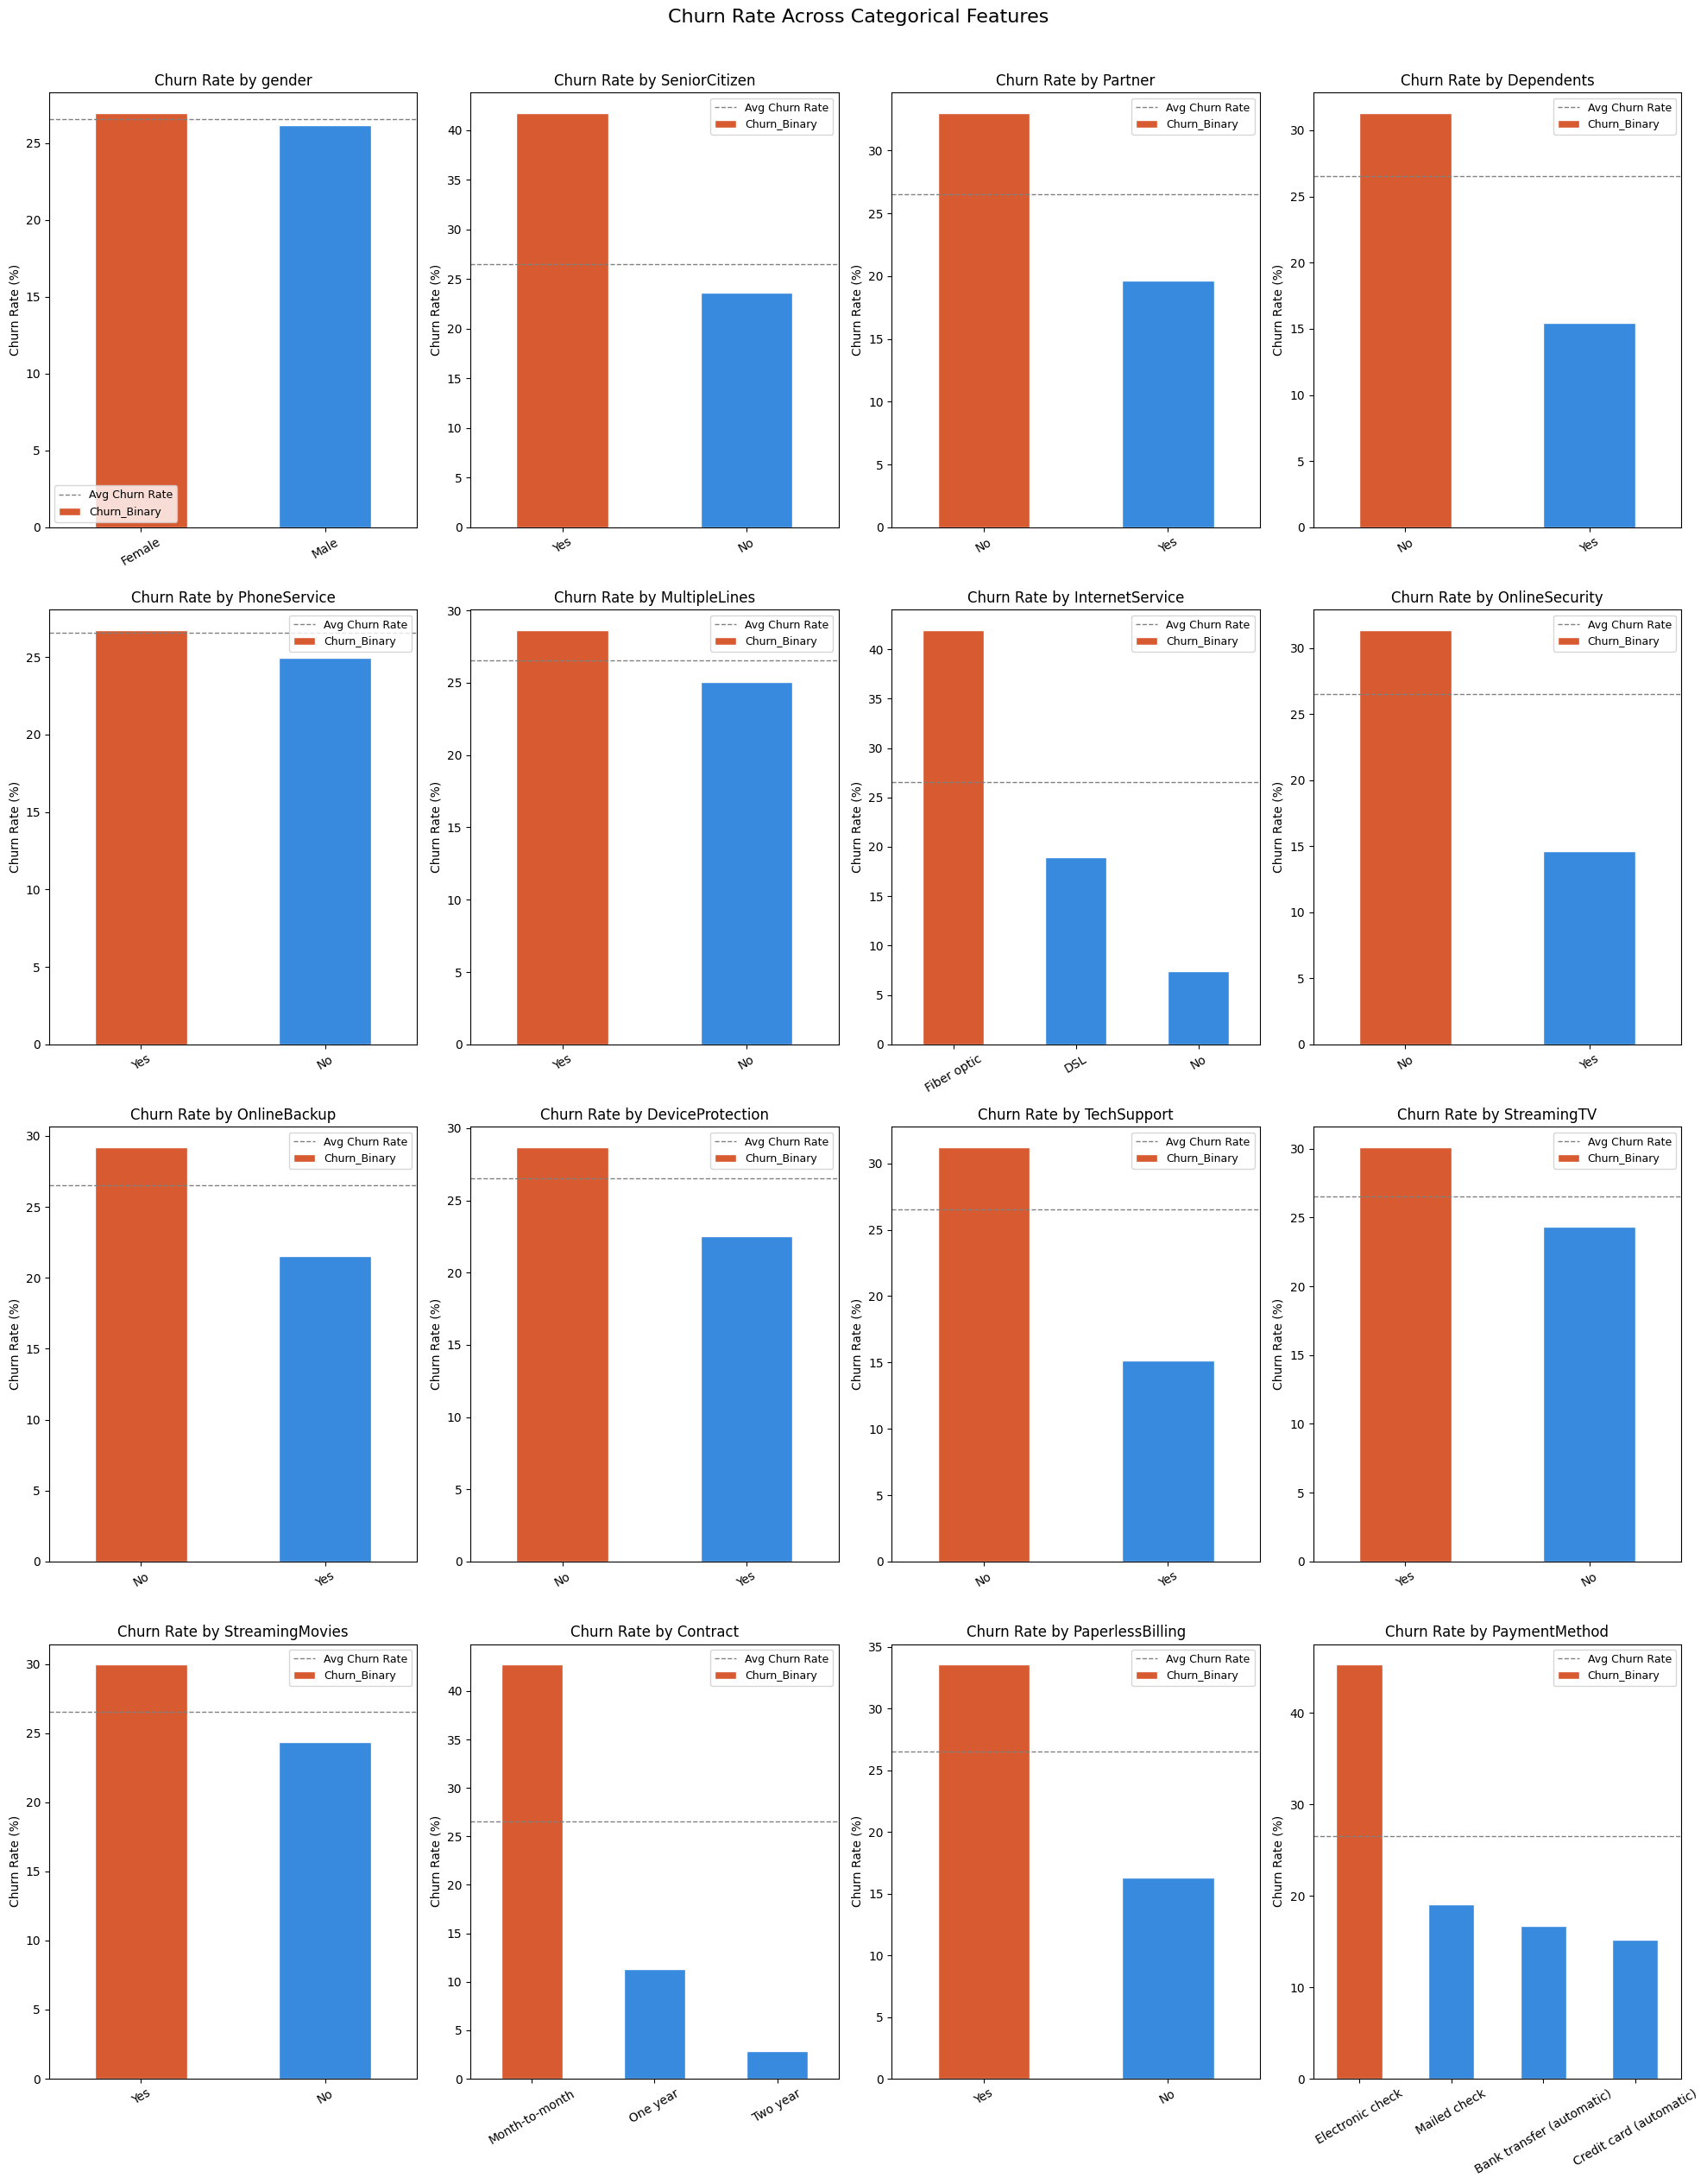

In [28]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(20,25))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn_Binary'].mean()*100
    churn_rate.sort_values(ascending=False).plot(
        kind='bar', ax=axes[i],
        color=['#D85A30' if x > df['Churn_Binary'].mean()*100 else '#378ADD' for x in churn_rate.sort_values(ascending=False)],
        edgecolor='white'
    )
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(y=df['Churn_Binary'].mean()*100, color='grey', linestyle='--', linewidth=1, label='Avg Churn Rate')
    axes[i].legend(fontsize=9)

plt.suptitle('Churn Rate Across Categorical Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('churn_rate_categorical_features.png',
            dpi=600,
            bbox_inches='tight')
plt.show()

## Numerical VS Churn
1. Customers who churned usually have much lower `tenure`

    - The median tenure for Churn = Yes is around `10 months`, while for Churn = No it is around `38 months`.
    - This suggests newer customers are more likely to leave, and long-term customers tend to stay.

2. Customers who churned tend to have higher `monthly charges`

    - The median MonthlyCharges for churned customers is around `80`, compared to about `65` for non-churned customers.
    - This suggests higher monthly bills may be linked to higher churn.

3. `TotalCharges` are lower for churned customers

    - Churned customers have a much lower median TotalCharges than non-churned customers.
    - This makes sense because they usually stay for a shorter time, so they accumulate less total spending.

4. The gap is strongest for `tenure` and `total charges`

    - tenure and TotalCharges show a clear separation between churned and non-churned groups.
    - That means these two features look very useful for predicting churn.

5. `MonthlyCharges` overlaps more

    - The monthly charge distributions for both groups overlap quite a bit.
    - So MonthlyCharges is still useful, but not as strongly separated as tenure.

6. `Outliers` are present

    - There are several outliers, especially in tenure and TotalCharges.
    - This means some customers have unusually high values compared to the rest.

The chart suggests that customers with low tenure and high monthly charges are more likely to churn. Among the three features, tenure looks like the strongest indicator of churn.

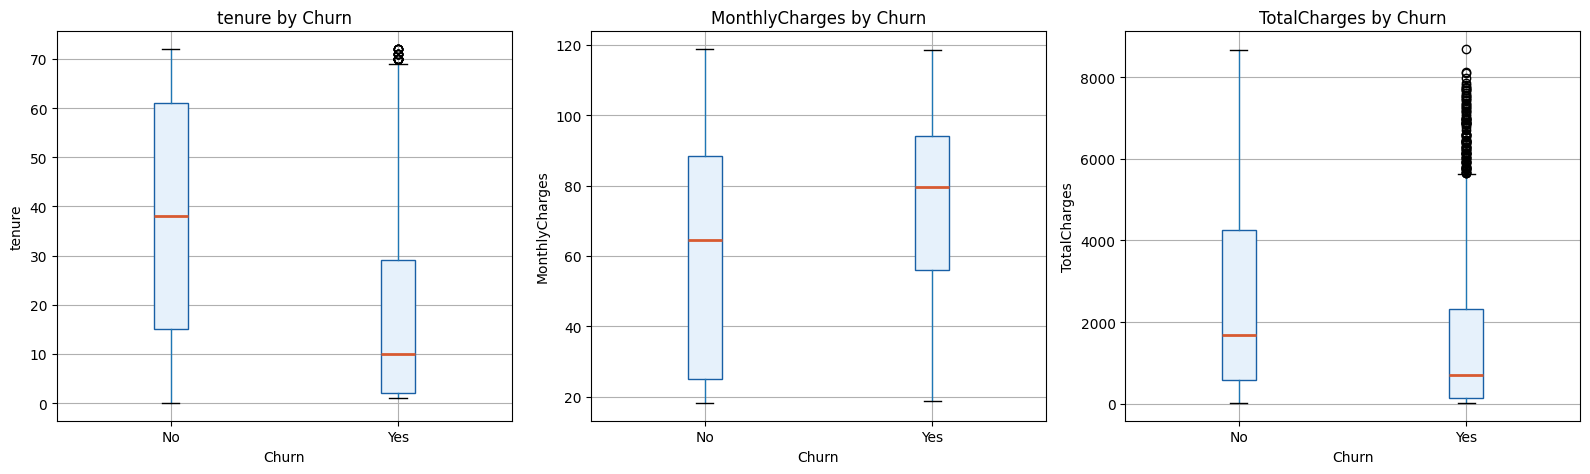

In [29]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1,3, figsize=(16,5))

for i, col in enumerate(num_cols):
    df.boxplot(column = col, by='Churn', ax=axes[i],
               patch_artist=True,
               boxprops=dict(facecolor='#E6F1FB', color='#185FA5'),
               medianprops=dict(color='#D85A30', linewidth=2))
    axes[i].set_title(f'{col} by Churn')
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel(col)

plt.suptitle('')
plt.tight_layout()
plt.savefig('Churn_rate_num_features.png',
            dpi=600,
            bbox_inches='tight'
           )
plt.show()

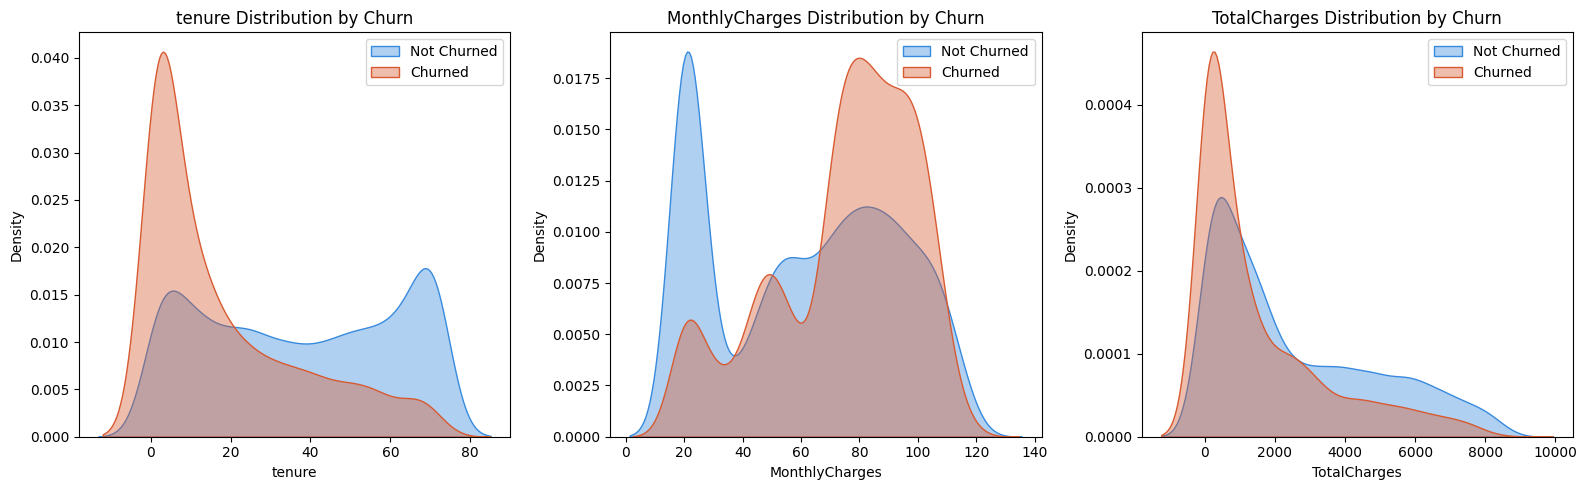

In [30]:
fig, axes = plt.subplots(1,3, figsize=(16,5))

for i, col in enumerate(num_cols):
    for churn_val, color, label in [('No', '#378ADD', 'Not Churned'), ('Yes', '#D85A30', 'Churned')]:
        sns.kdeplot(df[df['Churn'] == churn_val][col], ax=axes[i],
                    fill=True, alpha=0.4, color=color, label=label)
    axes[i].set_title(f'{col} Distribution by Churn')
    axes[i].set_xlabel(col)
    axes[i].legend()

plt.tight_layout()
plt.savefig('KDE_PLOT_Churners_vs_Non-Churners.png', dpi=600, bbox_inches='tight')
plt.show()

## T-tests For Numerical Columns

Is the difference between two averages real or just random chance? And the p-value tells you how confident you can be about that answer.

1. `TENURE`
    - Customers who churned stayed with the company for a much shorter time compared to customers who stayed.

        - Churned customers: ~18 months
        - Loyal customers: ~38 months
Customers are more likely to churn in the earlier stages of their relationship with the company.

2. `MonthlyCharges`

   - Customers who churned paid higher monthly bills on average.

This suggests that Higher monthly charges may increase the likelihood of churn.

3. `TotalCharges`
   - Customers who stayed have much higher total charges.
   - Customers who stay longer naturally accumulate larger total payments.
   
Long-term customers contribute more revenue and are less likely to churn.

4. Meaning of p-value = 0.0000
   - This means that The differences between churned and non-churned customers are statistically significant.
  
*Overall Conclusion*:
  
The t-test analysis revealed statistically significant differences in all key numerical features between churned and non-churned customers. Customers with lower tenure and higher monthly charges were more likely to churn, indicating that pricing and early customer experience are major churn drivers.

In [31]:
print('=== T-Test Results (Churned vs Not Churned) === \n')
for col in num_cols:
    churned = df[df['Churn'] == 'Yes'][col]
    not_churned = df[df['Churn'] == 'No'][col]
    t_stat, p_val = stats.ttest_ind(churned, not_churned)
    significance = "✓ Significant" if p_val < 0.05 else "✗ Not Significant"
    print(f"{col}:")
    print(f" Mean (Churned) : {churned.mean():.2f} | Mean (Not Churned) : {not_churned.mean():.2f}")
    print(f" p-value: {p_val:.4f} → {significance}\n")

=== T-Test Results (Churned vs Not Churned) === 

tenure:
 Mean (Churned) : 17.98 | Mean (Not Churned) : 37.57
 p-value: 0.0000 → ✓ Significant

MonthlyCharges:
 Mean (Churned) : 74.44 | Mean (Not Churned) : 61.27
 p-value: 0.0000 → ✓ Significant

TotalCharges:
 Mean (Churned) : 1531.80 | Mean (Not Churned) : 2550.00
 p-value: 0.0000 → ✓ Significant



## Chi-Square Tests + Cramer's V For Categorical Columns

Cramér's V is an effect size measurement for the Chi-square test. While the p-value tells you if there is a relationship (Yes/No), Cramér's V tells you how strong that relationship is on a scale of 0 to 1.

In [32]:
print("=== Chi-Square Test Results + Cramér's V (Categorical vs Churn) === \n")
results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p_val, dof, _ = stats.chi2_contingency(ct)
    n         = ct.sum().sum()
    k         = min(ct.shape)
    cramers_v = np.sqrt(chi2 / (n * (k - 1)))
    results.append({'Feature':col, 'Chi2':round(chi2,2), 'p-value':round(p_val,4), 
                    "Cramér's V" : round(cramers_v, 3),
                    'Association': 'Strong' if cramers_v >= 0.3 else ('Moderate' if cramers_v >= 0.15 else 'Weak'),
                    'Significant':'Yes' if p_val < 0.05 else 'No'})
results_df = pd.DataFrame(results).sort_values('Chi2', ascending=False)
print(results_df.to_string(index=False))

=== Chi-Square Test Results + Cramér's V (Categorical vs Churn) === 

         Feature    Chi2  p-value  Cramér's V Association Significant
        Contract 1184.60   0.0000       0.410      Strong         Yes
 InternetService  732.31   0.0000       0.322      Strong         Yes
   PaymentMethod  648.14   0.0000       0.303      Strong         Yes
PaperlessBilling  258.28   0.0000       0.191    Moderate         Yes
  OnlineSecurity  205.63   0.0000       0.171    Moderate         Yes
     TechSupport  190.17   0.0000       0.164    Moderate         Yes
      Dependents  189.13   0.0000       0.164    Moderate         Yes
   SeniorCitizen  159.43   0.0000       0.150    Moderate         Yes
         Partner  158.73   0.0000       0.150    Moderate         Yes
    OnlineBackup   47.26   0.0000       0.082        Weak         Yes
DeviceProtection   30.51   0.0000       0.066        Weak         Yes
     StreamingTV   27.86   0.0000       0.063        Weak         Yes
 StreamingMovies   2

## Cramér's V bar chart
1. The "Big Three" Drivers of Churn
    - The features Contract, InternetService, and PaymentMethod are your heavy hitters. With Cramér's V scores above 0.3, they have a strong association with whether a customer stays or leaves.
    
    - Contract (V = 0.410): This is your most powerful predictor. In telco data, "Month-to-month" customers typically churn at much higher rates than those on one- or two-year contracts.
    
    - InternetService (V = 0.322): This suggests the type of service (Fiber optic vs. DSL) is a major factor, possibly due to price points or service reliability.
    
    - PaymentMethod (V = 0.303): This often points to customers using "Electronic Check" being more likely to churn compared to those on automatic credit card payments.
  
2. Secondary Influence (The Service Bundle)

   - Features like PaperlessBilling, OnlineSecurity, and TechSupport show a moderate association (0.15 ≤ V < 0.3).
     
       - This suggests that customers who lack security or support features are more "at risk.
         
       - "Demographics: Factors like being a SeniorCitizen or having Dependents do matter, but they aren't the primary reasons for churn compared to the service logistics mentioned above.
  
3. The "Noise" (Irrelevant Features)

- You can statistically ignore PhoneService and gender for your churn prediction model.

    - p-values > 0.05: These are not statistically significant.
    
    - Cramér's V ≈ 0: The association is negligible.
    
    - Conclusion: Men and women churn at roughly the same rate, and having phone service alone doesn't tell you much about whether a customer will leave.

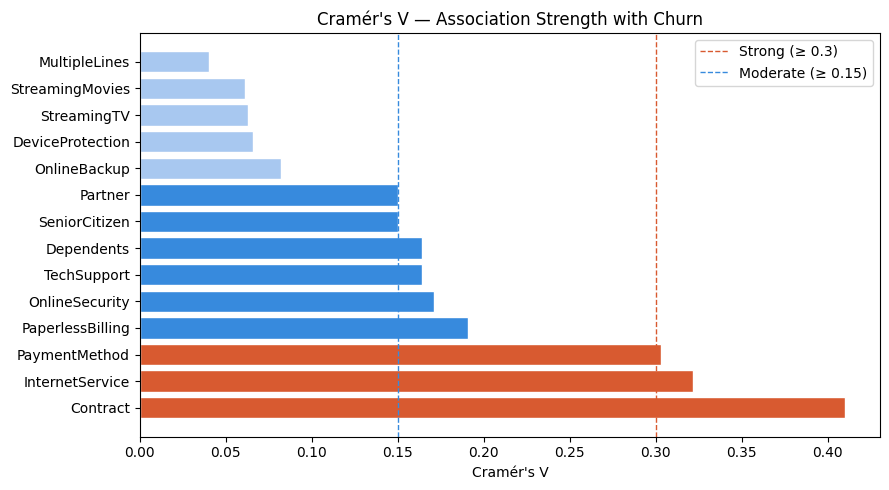

In [33]:
sig    = results_df[results_df['Significant'] == 'Yes'].copy()
colors = ['#D85A30' if v >= 0.3 else '#378ADD' if v >= 0.15 else '#A8C8F0'
          for v in sig["Cramér's V"]]
 
plt.figure(figsize=(9, 5))
plt.barh(sig['Feature'], sig["Cramér's V"], color=colors, edgecolor='white')
plt.axvline(x=0.3,  color='#D85A30', linestyle='--', linewidth=1, label='Strong (≥ 0.3)')
plt.axvline(x=0.15, color='#378ADD', linestyle='--', linewidth=1, label='Moderate (≥ 0.15)')
plt.title("Cramér's V — Association Strength with Churn")
plt.xlabel("Cramér's V")
plt.legend()
plt.tight_layout()
plt.savefig('cramers_v_churn.png', dpi=600, bbox_inches='tight')
plt.show()

## Correlation Heatmap
1. Tenure vs TotalCharges → Strong Positive Correlation (0.83)
    - Customers who stay longer with the company naturally pay higher total charges.

2. Tenure vs Churn → Moderate Negative Correlation (-0.35)
    - Customers with longer tenure are less likely to churn.
    - New customers churn more frequently. Loyal/old customers tend to stay.
    
3. MonthlyCharges vs Churn → Weak Positive Correlation (0.19)
    - Customers paying higher monthly charges are slightly more likely to churn.
    - Expensive plans may increase dissatisfaction. Customers may feel pricing is high.

4. TotalCharges vs Churn → Weak Negative Correlation (-0.20)
    - Customers who have paid more total charges are slightly less likely to churn. Because customers with high total charges usually stayed longer.

5. MonthlyCharges vs TotalCharges → Moderate Positive Correlation (0.65)
    - Customers with higher monthly bills tend to accumulate higher total charges.
  
6. MonthlyCharges vs Tenure → Weak Positive Correlation (0.25)
    - Customers staying longer may have slightly higher monthly charges.
  
*The strongest insight from this analysis is:*

Customer churn decreases significantly as customer tenure increases.

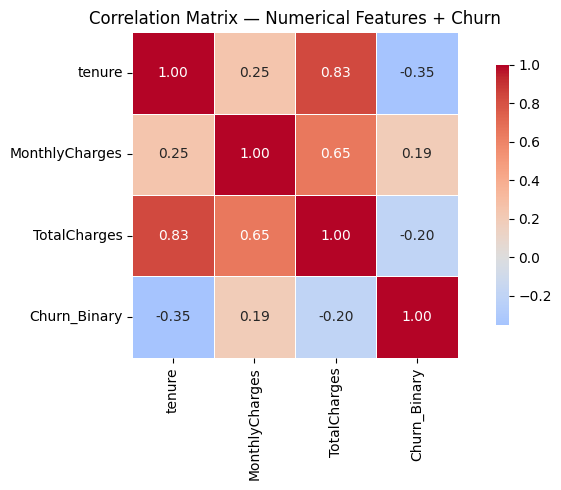

In [34]:
plt.figure(figsize=(8,5))

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidth=0.5, square=True,
            cbar_kws={'shrink':0.8})
plt.title('Correlation Matrix — Numerical Features + Churn')
plt.tight_layout()
plt.savefig('Correlation_Matrix.png', dpi=600, bbox_inches='tight')
plt.show()

## Scatter — tenure vs TotalCharges, coloured by churn

The scatter plot shows a positive relationship between tenure and total charges. Customers with longer tenure accumulate higher total charges. Churned customers are more concentrated at lower tenure values, indicating that newer customers are more likely to leave. Long-term customers tend to remain loyal, although some churn still occurs at higher tenure levels due to possible reasons : 
- better competitor offers
- dissatisfaction
- pricing issues
- service quality decline

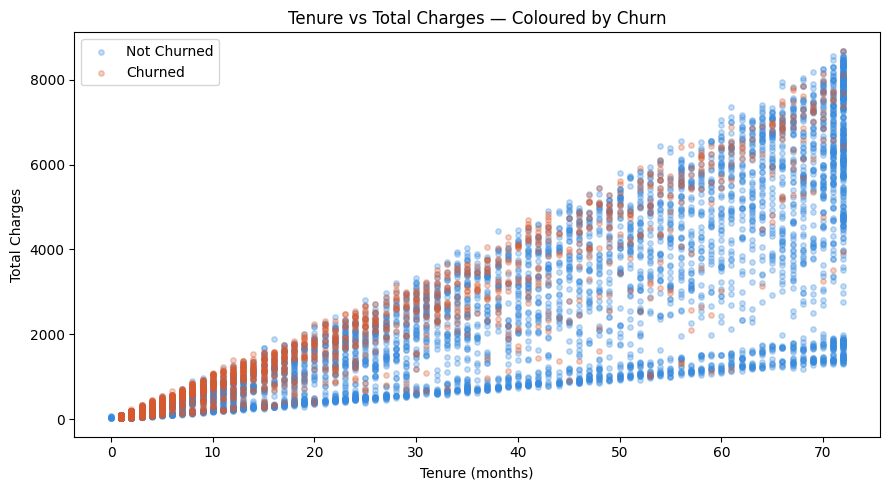

In [35]:
plt.figure(figsize=(9,5))
for churn_val, color, label in [('No', '#378ADD', 'Not Churned'), ('Yes', '#D85A30', 'Churned')]:
    subset = df[df['Churn'] == churn_val]
    plt.scatter(subset['tenure'], subset['TotalCharges'],
                alpha=0.3, color=color, label=label, s=15)

plt.xlabel('Tenure (months)')
plt.ylabel('Total Charges')
plt.title('Tenure vs Total Charges — Coloured by Churn')
plt.legend()
plt.tight_layout()
plt.savefig('Scatter_tenure_vs_totalCharges.png', dpi=600, bbox_inches='tight')
plt.show()

## MULTIVARIATE ANALYSIS

## PAIRPLOT

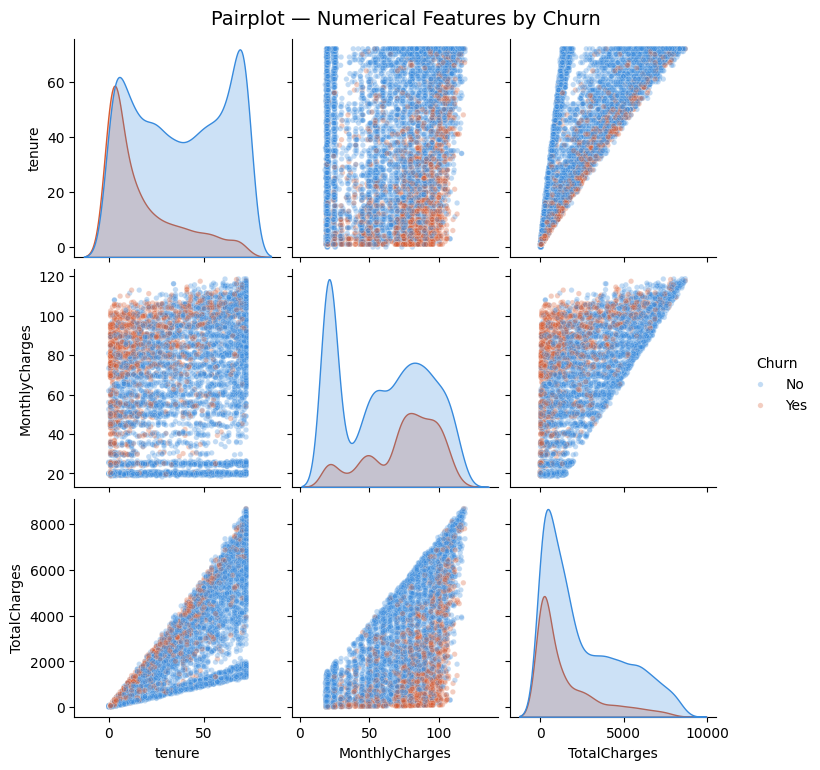

In [36]:
# Pairplot — numerical features coloured by Churn
sns.pairplot(
    df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']],
    hue='Churn',
    palette={'No': '#378ADD', 'Yes': '#D85A30'},
    plot_kws={'alpha': 0.3, 's': 15},
    diag_kind='kde'
)
plt.suptitle('Pairplot — Numerical Features by Churn', y=1.02, fontsize=14)
plt.savefig('Pairplot_Num_feature_by_churn.png', dpi=600, bbox_inches='tight')
plt.show()

## Contract × InternetService churn heatmap

1. Contract Length is the Dominant Driver of Churn
    - Month-to-month contracts have dramatically higher churn (avg. ~35%): 32.2% (DSL), 54.6% (Fiber optic), 18.9% (No).
    - One-year contracts moderate churn (avg. ~10%): 9.3% (DSL), 19.3% (Fiber optic), 2.5% (No).
    - Two-year contracts show very low churn (avg. ~3%): 1.9% (DSL), 7.2% (Fiber optic), 0.8% (No).
  
Insight: Longer commitments strongly reduce churn. Month-to-month customers are ~5-10x more likely to leave than two-year ones.

2. Fiber Optic Service Increases Churn Risk (Especially Short Contracts)
    - Across all contracts, Fiber optic has the highest churn in its column (avg. ~27%): Peaks at 54.6% for month-to-month.
    - DSL is moderate (avg. ~14%), better than Fiber but worse than "No".
    - No internet service has the lowest churn overall (avg. ~7%): Customers without internet are the most loyal (possibly lower expectations/costs).

Insight: Fiber optic users churn more—possibly due to higher performance demands, billing issues, or competitor offers.

3. Highest-Risk Segment (Red Zone)
    - Month-to-month + Fiber optic: 54.6% → Critical priority for interventions (e.g., upgrade offers, loyalty perks).
      
4. Lowest-Risk Segments (Green Zones)
    - Two-year + No/DSL: <2% → Stable, low-effort retention.
    - One/Two-year + No internet: ~1-3% → "Safest" group.

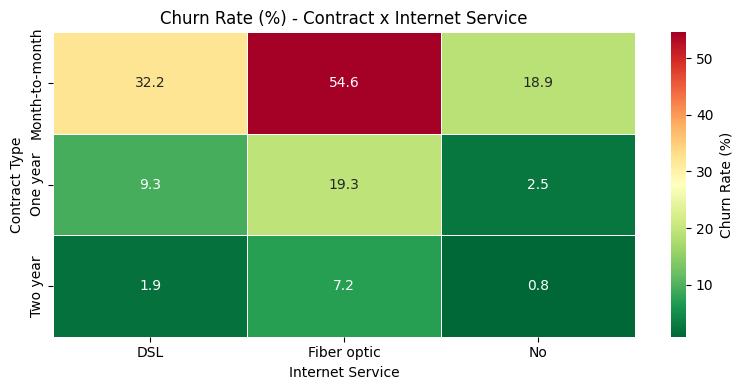

In [37]:
pivot1 = df.groupby(['Contract', 'InternetService'])['Churn_Binary'].mean()*100
pivot1 = pivot1.unstack()

plt.figure(figsize=(8,4))
sns.heatmap(pivot1, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidth=0.5, cbar_kws={'label':'Churn Rate (%)'})
plt.title('Churn Rate (%) - Contract x Internet Service')
plt.ylabel('Contract Type')
plt.xlabel('Internet Service')
plt.tight_layout()
plt.savefig('Contract_×_InternetService_churn_heatmap.png', dpi=600, bbox_inches='tight')
plt.show()

## Contract × PaymentMethod churn heatmap
1) Contract length is the strongest driver of churn
    - Churn drops sharply as contract commitment increases, regardless of payment method:

        - Month-to-month: ~31.6%–53.7% (very high)
        - One year: ~6.8%–18.4% (much lower)
        - Two year: ~0.8%–7.7% (lowest)
So, getting customers off month-to-month and into longer contracts is strongly associated with retention.

2) Payment method matters most for month-to-month customers
    - Within month-to-month, churn varies a lot by payment type:

        - Electronic check: 53.7% (highest churn overall)
        - Bank transfer (auto): 34.1%
        - Credit card (auto): 32.8%
        - Mailed check: 31.6% (lowest among month-to-month, but still high)
So electronic check + month-to-month is the highest-risk segment.

3) Auto-pay and longer contracts are associated with the lowest churn
    - The lowest churn cells are among two-year contracts, especially:

        - Mailed check + two-year: 0.8% (lowest)
        - Credit card (auto) + two-year: 2.2%
        - Bank transfer (auto) + two-year: 3.4%
In general: two-year + (auto-pay) is a very “sticky” combination.

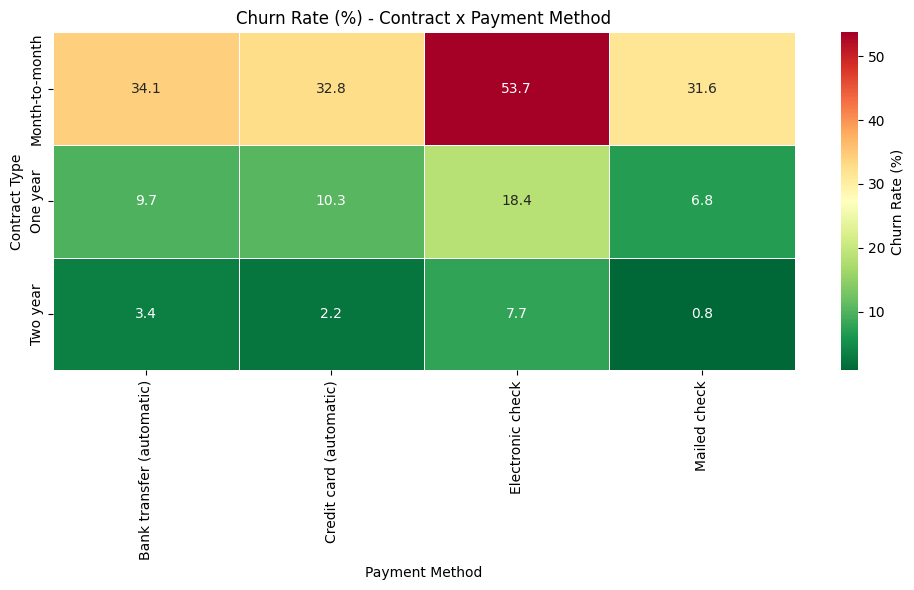

In [38]:
pivot2 = df.groupby(['Contract', 'PaymentMethod'])['Churn_Binary'].mean()*100
pivot2 = pivot2.unstack()

plt.figure(figsize=(10,6))
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidth=0.5, cbar_kws={'label':'Churn Rate (%)'})
plt.title('Churn Rate (%) - Contract x Payment Method')
plt.ylabel('Contract Type')
plt.xlabel('Payment Method')
plt.tight_layout()
plt.savefig('Churn_Rate_(%)_Contract_x_PaymentMethod.png', dpi=600, bbox_inches='tight')
plt.show()

## PaymentMethod x Internet Service Churn Heatmap

1. The Critical "Red Zone": Fiber Optic + Electronic Check
   
- The most striking insight is the 53.2% churn rate for customers who have Fiber optic and pay via Electronic check.

    - The Problem: Over half of the customers in this segment are leaving. This is significantly higher than any other category.
      
    - Usually, Fiber optic is more expensive. If "Electronic check" is a manual monthly process (rather than automated), customers face "bill shock" every time they manually pay a high bill, making them more likely to reconsider the service.
 
2. Automatic Payments are the "Anchor"

- There is a massive disparity between manual and automatic payment methods across all service types.

    - Automatic (Bank Transfer/Credit Card): Churn rates are generally low, particularly for DSL and No-internet users (ranging from 2.7% to 12.1%).
        
    - Manual (Electronic/Mailed Check): Churn rates spike dramatically. Even for basic DSL, paying by Electronic check jumps the churn to 31.9%.
    
    - Conclusion: Automatic payments create "passive loyalty"—customers stay because they don't have to think about the transaction.
 
3. Fiber Optic is a Churn Magnet
   
- Regardless of the payment method, Fiber optic users churn at much higher rates than DSL users.

    - Even with the "safest" payment method (Credit card), Fiber optic churn is 25.3%, which is more than double the DSL churn rate of 12.1% for the same payment type.
    
    - Strategic Question: Is the Fiber optic service overpriced, or are there technical reliability issues (outages) causing this dissatisfaction?
 
4. The "No Internet" Safe Haven
   
- Customers with no internet service (likely phone-only customers) are your most stable segment.

    - Their churn rates are almost entirely in the "green" (low), peaking at only 12.3% for Electronic checks.
    
    - This confirms that the primary drivers of churn in your business are tied to the internet product offerings, not the core phone service.

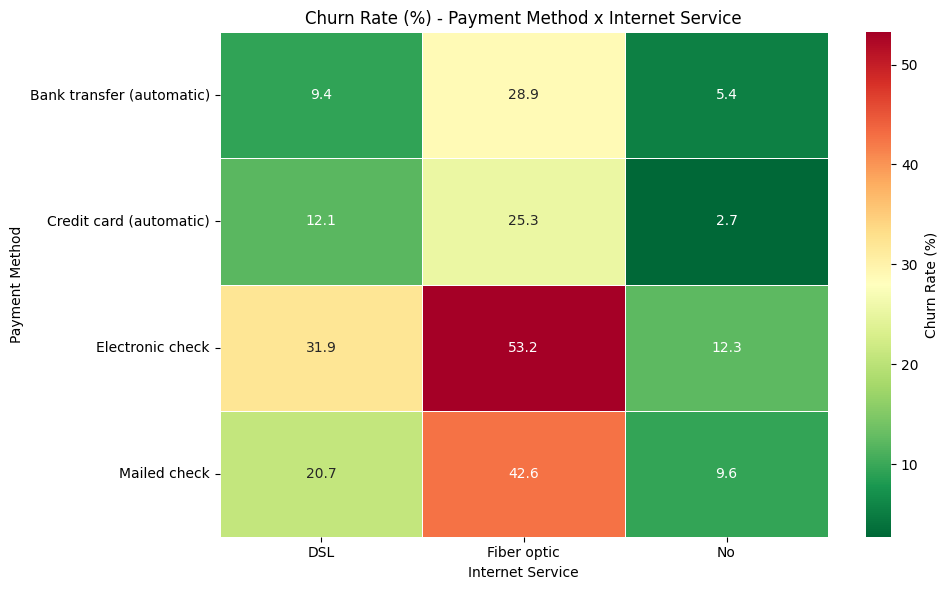

In [39]:
pivot4 = df.groupby(['PaymentMethod', 'InternetService'])['Churn_Binary'].mean()*100
pivot4 = pivot4.unstack()

plt.figure(figsize=(10,6))
sns.heatmap(pivot4, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidth=0.5, cbar_kws={'label':'Churn Rate (%)'})
plt.title('Churn Rate (%) - Payment Method x Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Payment Method')
plt.tight_layout()
plt.savefig('Churn Rate (%) - Payment Method x Internet Service.png', dpi=600, bbox_inches='tight')
plt.show()

## Churn rate across tenure buckets × contract
1. Month-to-Month Contracts are High Risk
    - In the first year (0-12 months), more than 50% of month-to-month customers leave.
    - Even as tenure increases, this group remains the most "at-risk" segment compared to those on fixed-term contracts.

2. Tenure is a Natural Churn Buffer
    - As customers stay longer, their likelihood of leaving drops (from ~51% in the first year to ~26% in the 49-72 month group).
    - Conclusion: If you can keep a flexible-contract customer past the first year, their "stickiness" improves substantially.

3. Long-Term Contracts Effectively "Lock In" Loyalty
    - One-year contracts keep churn consistently low (mostly between 8% and 12%).
    - Two-year contracts (green bars) result in almost negligible churn. In fact, they don't even appear in the first two tenure groups on your chart, likely because those customers haven't reached a renewal window or the sample size is very stable.
    - Conclusion: Moving customers from month-to-month to even a 1-year contract drastically reduces the probability of churn, especially for new customers.
    
4. The "New Customer" Danger Zone
    - The 0-12 month window for Month-to-month users is your biggest vulnerability.
    - The massive gap between the orange bar and the blue bar in the first group suggests that the lack of a contract, combined with a lack of brand history, makes it very easy for new customers to walk away.

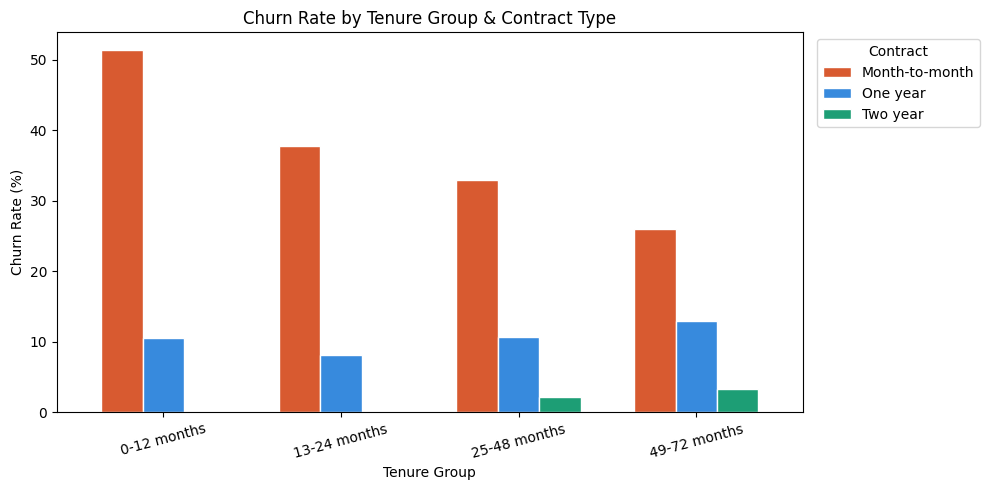

In [40]:
df['tenure_group'] = pd.cut(df['tenure'],
                            bins = [0,12,24,48,72],
                            labels = ['0-12 months', '13-24 months', '25-48 months', '49-72 months'],
                            include_lowest = True
                           )

pivot3 = df.groupby(['tenure_group', 'Contract'])['Churn_Binary'].mean()*100
pivot3 = pivot3.unstack()

pivot3.plot(kind='bar', figsize=(10,5),
            color=['#D85A30', '#378ADD', '#1D9E75'],
            edgecolor='white', width=0.7)
plt.title('Churn Rate by Tenure Group & Contract Type')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
plt.legend(title='Contract', bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.savefig('Churn Rate by Tenure Group & Contract Type.png', dpi=600, bbox_inches='tight')
plt.show()

## Number of add-on services vs churn rate

1. The "Sweet Spot" for Retention (3+ Services)
   
There is a clear downward trend in churn as the number of services increases from 1 to 6.

- Customers with 3 or more services begin to drop below the average churn rate (the gray dashed line).
- By the time a customer has 6 services, the churn rate is almost negligible (under 10%).
- Conclusion: The more integrated a customer is into your ecosystem, the higher the "switching cost" (the effort/pain of moving to a competitor).

2. The "Danger Zone" (1–2 Services)
   
Counter-intuitively, customers with 0 services actually churn less than those with 1 or 2 services.

- Customers with just 1 service are your highest risk group, with a churn rate approaching 45%.
- The Logic: A customer with 0 add-ons might be a "basic" user who is satisfied with just the core product. However, a customer with only 1 or 2 add-ons may be testing the waters or finding that the limited bundle doesn't provide enough value to justify the extra cost, leading to higher dissatisfaction.

3. The "Lock-in" Effect

- When a customer uses 4, 5, or 6 services (like Online Security, Tech Support, and Streaming), they aren't just buying a product; they are building a digital infrastructure with you.
- Moving to a competitor would mean replacing six different touchpoints, which creates a significant barrier to leaving.

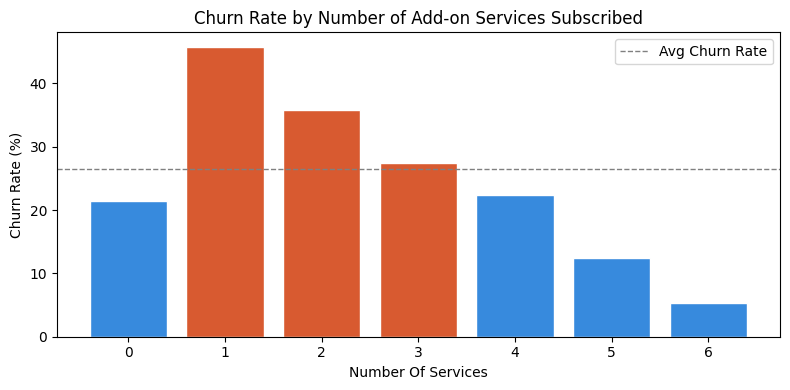

num_services
0    21.4
1    45.8
2    35.8
3    27.4
4    22.3
5    12.4
6     5.3
Name: Churn_Binary, dtype: float64


In [41]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

df['num_services'] = df[service_cols].apply(lambda row : (row == 'Yes').sum(), axis=1)

services_churn = df.groupby('num_services')['Churn_Binary'].mean()*100

plt.figure(figsize=(8,4))
bars = plt.bar(services_churn.index, services_churn.values,
               color = ['#D85A30' if v > df['Churn_Binary'].mean()*100 else '#378ADD'
                        for v in services_churn.values],
               edgecolor='white')
plt.axhline(y=df['Churn_Binary'].mean()*100, color='gray',
            linestyle='--', linewidth=1, label='Avg Churn Rate')
plt.title('Churn Rate by Number of Add-on Services Subscribed')
plt.xlabel('Number Of Services')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('Churn Rate by Number of Add-on Services Subscribed.png', dpi=600, bbox_inches='tight')
plt.show()

print(services_churn.round(1))

## High-risk segment summary

In [42]:
segments = {
    'Month-to-Month + Fibre Optic':
        df[(df['Contract'] == 'Month-to-month') & (df['InternetService'] == 'Fiber optic')]
    ['Churn_Binary'].mean(),
    'Month-to-Month + Electronic Check':
        df[(df['Contract'] == 'Month-to-month') & (df['PaymentMethod'] == 'Electronic check')]
    ['Churn_Binary'].mean(),
    'Tenure 0–12 months + No Security':
        df[(df['tenure'] <= 12) & (df['OnlineSecurity'] == 'No')]
    ['Churn_Binary'].mean(),
    '1 Add-on Services':
        df[df['num_services'] == 1]['Churn_Binary'].mean(),
    'Senior + Month-to-Month':
        df[(df['SeniorCitizen'] == 'Yes') & (df['Contract'] == 'Month-to-month')]
    ['Churn_Binary'].mean(),
}

summary_df = pd.DataFrame.from_dict(segments, orient='index', columns=['Churn Rate'])
summary_df['Churn Rate'] = (summary_df['Churn Rate'] * 100).round(1).astype(str) + '%'
summary_df.index.name = 'Segment'
print('\n=== HIGH-RISK SEGMENT SUMMARY ===\n')
print(summary_df.to_string())


=== HIGH-RISK SEGMENT SUMMARY ===

                                  Churn Rate
Segment                                     
Month-to-Month + Fibre Optic           54.6%
Month-to-Month + Electronic Check      53.7%
Tenure 0–12 months + No Security       49.3%
1 Add-on Services                      45.8%
Senior + Month-to-Month                54.6%


## Multivariate Analysis — Key Findings

**Highest-risk profile:** Month-to-month contract + Fiber Optic + Electronic Check + tenure < 12 months

**Compound segments:**
- Contract × InternetService: Month-to-month Fiber Optic customers are the primary churn segment
- Contract × PaymentMethod: Electronic check users on monthly contracts churn most
- PaymentMethod × InternetService : Fiber Optic pay via Electronic Check churn most

**Tenure lifecycle:**
- Churn risk is highest in the first 12 months and drops sharply after 24 months
- Annual/2-year contract customers show near-flat churn across all tenure groups

**Services as retention lever:**
- Customers with 1 add-on services churn at ~2x the average rate
- Each additional service subscribed reduces churn probability

## Feature Engineering

In [43]:
# Drop EDA-only columns not used in modelling
df_model = df.drop(columns=[
    'Churn',           # replaced by Churn_Binary
    'Churn_Binary',    # this is our target — keep separate
    'tenure_group',    # binned version, tenure kept as-is
])

# Separate target
X = df_model
y = df['Churn_Binary']

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Churn rate: {y.mean()*100:.1f}%")

Feature matrix shape: (7043, 20)
Target shape: (7043,)
Churn rate: 26.5%


In [44]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [45]:
# 1. Charges per month relative to tenure (avg monthly spend)
#    Creates a normalised charge metric that captures spending intensity independent of tenure length.
X['AvgMonthlySpend'] = X['TotalCharges'] / (X['tenure'] + 1)

# 2. Number of add-on services (already created, carry forward)
# num_services is already in X from multivariate section

# 3. High-risk flag: month-to-month + fiber optic (strongest compound segment)
X['HighRisk_Flag'] = (
    (X['Contract'] == 'Month-to-month') &
    (X['InternetService'] == 'Fiber optic')
).astype(int)

# 4. Has any security service (OnlineSecurity or TechSupport)
X['HasSupportService'] = (
    (X['OnlineSecurity'] == 'Yes') |
    (X['TechSupport'] == 'Yes')
).astype(int)

# 5. Is auto-pay (reduces friction, lower churn historically)
X['IsAutoPay'] = X['PaymentMethod'].isin(
    ['Bank transfer (automatic)', 'Credit card (automatic)']
).astype(int)

print("New features added:")
print(["AvgMonthlySpend", "HighRisk_Flag", "HasSupportService", "IsAutoPay"])
print(f"\nUpdated feature matrix shape: {X.shape}")

New features added:
['AvgMonthlySpend', 'HighRisk_Flag', 'HasSupportService', 'IsAutoPay']

Updated feature matrix shape: (7043, 24)


In [46]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             7043 non-null   str    
 1   SeniorCitizen      7043 non-null   str    
 2   Partner            7043 non-null   str    
 3   Dependents         7043 non-null   str    
 4   tenure             7043 non-null   int64  
 5   PhoneService       7043 non-null   str    
 6   MultipleLines      7043 non-null   str    
 7   InternetService    7043 non-null   str    
 8   OnlineSecurity     7043 non-null   str    
 9   OnlineBackup       7043 non-null   str    
 10  DeviceProtection   7043 non-null   str    
 11  TechSupport        7043 non-null   str    
 12  StreamingTV        7043 non-null   str    
 13  StreamingMovies    7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  PaperlessBilling   7043 non-null   str    
 16  PaymentMethod      7043 non-null   

In [47]:
# Columns with simple Yes/No values → map to 1/0
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling', 'SeniorCitizen'
]

binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
X[binary_cols] = X[binary_cols].replace(binary_map)
X[binary_cols] = X[binary_cols].astype(int)

print("Binary encoded columns:")
print(X[binary_cols].head(3))

Binary encoded columns:
   gender  Partner  Dependents  PhoneService  PaperlessBilling  SeniorCitizen
0       0        1           0             0                 1              0
1       1        0           0             1                 0              0
2       1        0           0             1                 1              0


In [48]:
# Service columns with 2 levels: Yes / No 
service_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

service_map = {'Yes': 1, 'No': 0}
X[service_cols] = X[service_cols].replace(service_map)
X[service_cols] = X[service_cols].astype(int)

print("Service columns encoded:")
print(X[service_cols].head(3))

Service columns encoded:
   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
0              0               0             1                 0            0   
1              0               1             0                 1            0   
2              0               1             1                 0            0   

   StreamingTV  StreamingMovies  
0            0                0  
1            0                0  
2            0                0  


In [49]:
# Contract has a natural order: month-to-month < one year < two year
contract_map = {
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
}
X['Contract'] = X['Contract'].map(contract_map)
X['Contract'] = X['Contract'].astype(int)

print("Contract encoded:")
print(X['Contract'].value_counts())

Contract encoded:
Contract
0    3875
2    1695
1    1473
Name: count, dtype: int64


In [50]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             7043 non-null   int64  
 1   SeniorCitizen      7043 non-null   int64  
 2   Partner            7043 non-null   int64  
 3   Dependents         7043 non-null   int64  
 4   tenure             7043 non-null   int64  
 5   PhoneService       7043 non-null   int64  
 6   MultipleLines      7043 non-null   int64  
 7   InternetService    7043 non-null   str    
 8   OnlineSecurity     7043 non-null   int64  
 9   OnlineBackup       7043 non-null   int64  
 10  DeviceProtection   7043 non-null   int64  
 11  TechSupport        7043 non-null   int64  
 12  StreamingTV        7043 non-null   int64  
 13  StreamingMovies    7043 non-null   int64  
 14  Contract           7043 non-null   int64  
 15  PaperlessBilling   7043 non-null   int64  
 16  PaymentMethod      7043 non-null   

In [51]:
# No natural order → one-hot encode
# drop_first=True avoids dummy variable trap
X = pd.get_dummies(X, columns=['InternetService', 'PaymentMethod'], drop_first=True)

print("After one-hot encoding:")
print([c for c in X.columns if 'InternetService' in c or 'PaymentMethod' in c])

After one-hot encoding:
['InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [52]:
from sklearn.preprocessing import StandardScaler
import numpy as np

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'num_services']

# Force all to numeric first
for col in num_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Check what got coerced to NaN
print("Nulls after coerce:\n", X[num_cols].isnull().sum())

# Fill any NaNs
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

Nulls after coerce:
 tenure             0
MonthlyCharges     0
TotalCharges       0
AvgMonthlySpend    0
num_services       0
dtype: int64


In [53]:
# Confirm no nulls, no object dtypes remaining
print("=== FINAL FEATURE MATRIX CHECK ===\n")
print(f"Shape: {X.shape}")
print(f"\nNull values: {X.isnull().sum().sum()}")
print(f"\nObject dtype columns (should be 0):")
print(X.select_dtypes('object').columns.tolist())
print(f"\nAll columns:\n{X.columns.tolist()}")

=== FINAL FEATURE MATRIX CHECK ===

Shape: (7043, 27)

Null values: 0

Object dtype columns (should be 0):
[]

All columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'num_services', 'AvgMonthlySpend', 'HighRisk_Flag', 'HasSupportService', 'IsAutoPay', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


=== TARGET DISTRIBUTION ===

Churn_Binary
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


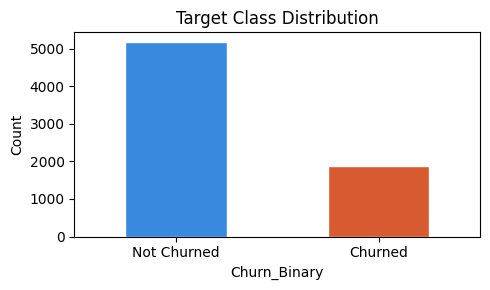

In [54]:
# Check target balance
print("=== TARGET DISTRIBUTION ===\n")
print(y.value_counts())
print(f"\nChurn rate: {y.mean()*100:.1f}%")

# Visualise
plt.figure(figsize=(5, 3))
y.value_counts().plot(kind='bar', color=['#378ADD', '#D85A30'], edgecolor='white')
plt.xticks([0, 1], ['Not Churned', 'Churned'], rotation=0)
plt.title('Target Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Feature Engineering — Summary

**Dropped:** Churn (string), tenure_group (binned EDA column)

**Interaction features created:**
- `AvgMonthlySpend` — TotalCharges / (tenure + 1), reduces multicollinearity
- `HighRisk_Flag` — Month-to-month + Fiber Optic compound flag
- `HasSupportService` — OnlineSecurity OR TechSupport = Yes
- `IsAutoPay` — Bank transfer or Credit card (automatic)
- `num_services` — count of add-on services (from multivariate section)

**Encoding:**
- Binary Yes/No columns → 0/1
- Service 2-level columns → collapsed to 0/1
- Contract → ordinal (0/1/2)
- InternetService, PaymentMethod → one-hot (drop_first=True)

## MODELLING

In [55]:
# %pip install xgboost

In [56]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Train Size : {X_train.shape[0]} rows")
print(f"Test Size : {X_test.shape[0]} rows")
print(f"Churn Rate in train : {y_train.mean()*100:.1f}%")
print(f"Churn Rate in test : {y_test.mean()*100:.1f}%")

Train Size : 5634 rows
Test Size : 1409 rows
Churn Rate in train : 26.5%
Churn Rate in test : 26.5%


# *LOGISTIC REGRESSION*

In [58]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("=== LOGISTIC REGRESSION ===\n")
print(classification_report(y_test, y_pred_lr, target_names=['Not Churned', 'Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

=== LOGISTIC REGRESSION ===

              precision    recall  f1-score   support

 Not Churned       0.90      0.73      0.81      1035
     Churned       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC: 0.8476


## *RANDOM FOREST*

In [59]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print('=== RANDOM FOREST ===\n')
print(classification_report(y_test, y_pred_rf, target_names=['Not Churned', 'Churned']))
print(f'ROC_AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')

=== RANDOM FOREST ===

              precision    recall  f1-score   support

 Not Churned       0.88      0.80      0.84      1035
     Churned       0.56      0.69      0.61       374

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.77      0.78      1409

ROC_AUC: 0.8395


## *XGBOOST CLASSIFIER*

In [60]:
# scale_pos_weight handles imbalance for XGBoost
neg, pos = (y_train==0).sum(), (y_train==1).sum()
scale = neg/pos

xgb = XGBClassifier(
    n_estimators=200, 
    max_depth=5, 
    learning_rate=0.05, 
    scale_pos_weight=scale, 
    use_label_encoder=False, 
    eval_metric='logloss', 
    random_state=42, 
    n_jobs=-1
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("=== XGBOOST ===\n")
print(classification_report(y_test, y_pred_xgb, target_names=['Not Churned', 'Churned']))
print(f"ROC_AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

=== XGBOOST ===

              precision    recall  f1-score   support

 Not Churned       0.90      0.75      0.82      1035
     Churned       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

ROC_AUC: 0.8429


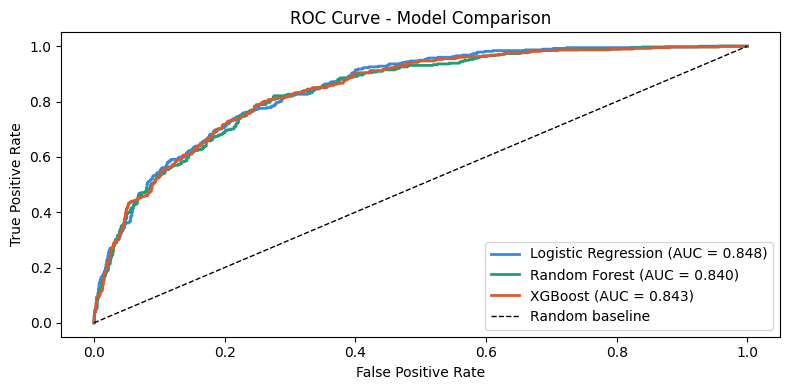

In [61]:
plt.figure(figsize=(8,4))

models = {
    'Logistic Regression' : y_prob_lr,
    'Random Forest' : y_prob_rf,
    'XGBoost' : y_prob_xgb
} 
colors = ['#378ADD', '#1D9E75', '#D85A30']

for (name, prob), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('ROC Curve - Model Comparison.png', dpi=600, bbox_inches='tight')
plt.show()

## *Confusion Matrix*

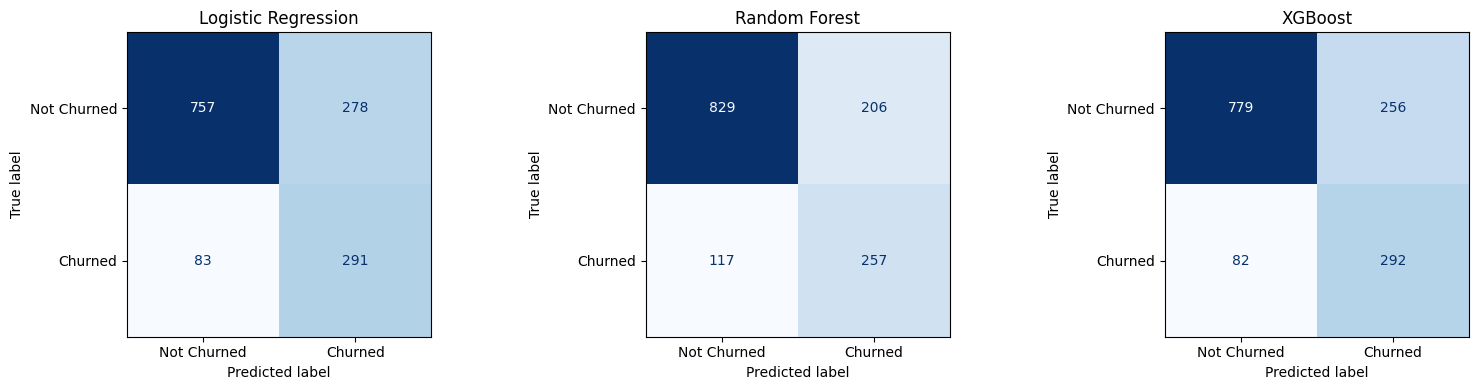

In [62]:
fig, axes = plt.subplots(1,3, figsize=(16,4)) 
models = {'Logistic Regression': y_pred_lr,
    'Random Forest'      : y_pred_rf,
    'XGBoost'            : y_pred_xgb,
         }
for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Churned', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.savefig('Confusion matrix.png', dpi=600, bbox_inches='tight')
plt.show()

## *Summary Metric Table*

In [63]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = []
for name, y_pred, y_prob in [
    ('Logistic Regression', y_pred_lr, y_prob_lr),
    ('Random Forest',       y_pred_rf, y_prob_rf),
    ('XGBoost',             y_pred_xgb, y_prob_xgb),
]:
    results.append({
        'Model' : name,
        'Precision' : round(precision_score(y_test, y_pred), 3),
        'Recall' : round(recall_score(y_test, y_pred), 3),
        'F1' : round(f1_score(y_test, y_pred), 3),
        'ROC-AUC' : round(roc_auc_score(y_test, y_prob), 3),
    })

results_df = pd.DataFrame(results).set_index('Model')
print('=== MODEL COMPARISON SUMMARY ===\n')
print(results_df.to_string())

=== MODEL COMPARISON SUMMARY ===

                     Precision  Recall     F1  ROC-AUC
Model                                                 
Logistic Regression      0.511   0.778  0.617    0.848
Random Forest            0.555   0.687  0.614    0.840
XGBoost                  0.533   0.781  0.633    0.843


## *Feature Importance*

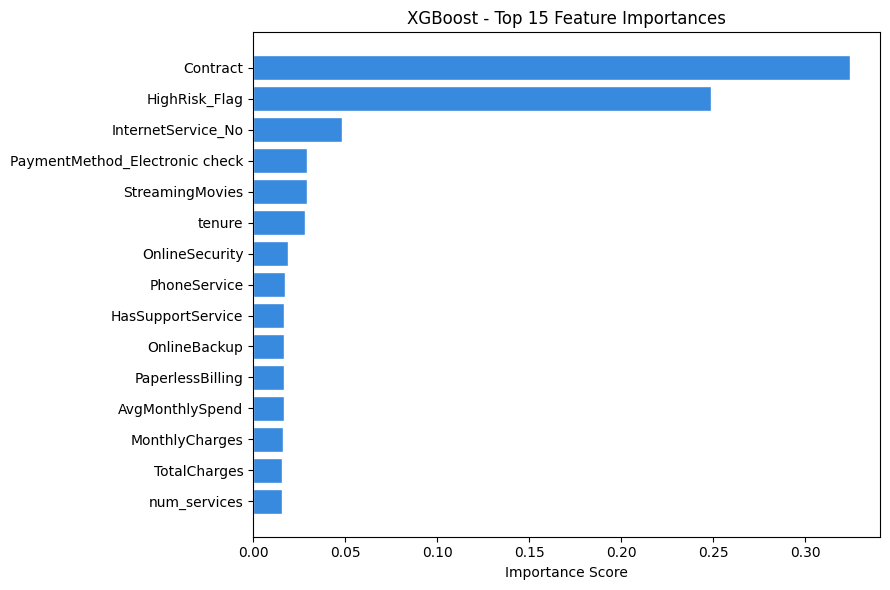

                       Feature  Importance
                      Contract    0.324394
                 HighRisk_Flag    0.248967
            InternetService_No    0.048049
PaymentMethod_Electronic check    0.029151
               StreamingMovies    0.029137
                        tenure    0.028116
                OnlineSecurity    0.019022
                  PhoneService    0.017392
             HasSupportService    0.016989
                  OnlineBackup    0.016941
              PaperlessBilling    0.016732
               AvgMonthlySpend    0.016615
                MonthlyCharges    0.016092
                  TotalCharges    0.015653
                  num_services    0.015432


In [64]:
importance_df = pd.DataFrame({
    'Feature' : X.columns,
    'Importance' : xgb.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9,6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='#378ADD', edgecolor='white')
plt.xlabel('Importance Score')
plt.title('XGBoost - Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('XGBoost - Top 15 Feature Importances.png', dpi=600, bbox_inches='tight')
plt.show()

print(importance_df.to_string(index=False))

## Modelling — Summary

**Models trained:** Logistic Regression (baseline), Random Forest, XGBoost

**Imbalance handling:**
- Logistic Regression & Random Forest → class_weight='balanced'
- XGBoost → scale_pos_weight = (non-churners / churners)

**Key metric to optimise:** ROC-AUC + Recall for Churned class
- High recall = fewer missed churners = better retention
- Balance with precision to avoid over-alerting on non-churners


## *Threshold Tuning*

In [65]:
from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb) 

# F1 at each threshold
f1_scores = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1]+1e-9)
optimal_idx = f1_scores.argmax()
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (max F1) : {optimal_threshold:.3f}")
print(f"F1 at Optimal Threshold : {f1_scores[optimal_idx]:.3f}")
print(f"Precision at Optimal Threshold : {precisions[optimal_idx]:.3f}")
print(f"Recall at Optimal Threshold : {recalls[optimal_idx]:.3f}")

Optimal Threshold (max F1) : 0.499
F1 at Optimal Threshold : 0.637
Precision at Optimal Threshold : 0.534
Recall at Optimal Threshold : 0.789


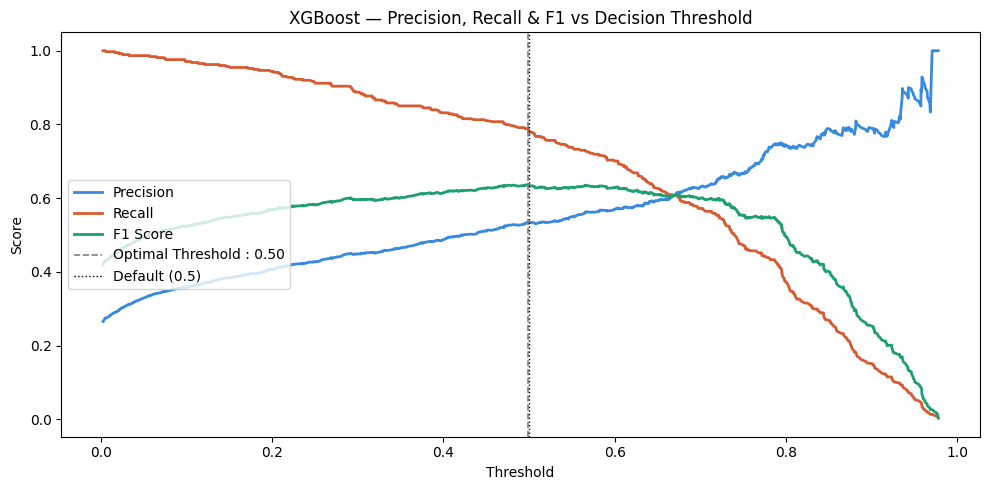

In [66]:
plt.figure(figsize=(10,5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='#378ADD', linewidth=2)
plt.plot(thresholds, recalls[:-1], label='Recall', color='#D85A30', linewidth=2)
plt.plot(thresholds, f1_scores, label='F1 Score', color='#1D9E75', linewidth=2)
plt.axvline(x=optimal_threshold, color='gray', linestyle='--', linewidth=1.2, label=f'Optimal Threshold : {optimal_threshold:.2f}')
plt.axvline(x=0.5, color='black', linestyle=':', linewidth=1, label='Default (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('XGBoost — Precision, Recall & F1 vs Decision Threshold')
plt.legend(loc='center left')
plt.tight_layout()
plt.savefig('XGBoost — Precision, Recall & F1 vs Decision Threshold', dpi=600, bbox_inches='tight')
plt.show()

In [67]:
target_recall = 0.85
valid_idx = np.where(recalls[:-1] > target_recall)[0]
business_threshold = thresholds[valid_idx[np.argmax(precisions[valid_idx])]]

print(f"Business Threshold (recall >= 0.85) : {business_threshold:.3f}")
print(f"Precision at this Threshold : {precisions[valid_idx].max():.3f}")

Business Threshold (recall >= 0.85) : 0.373
Precision at this Threshold : 0.479


=== BUSINESS THRESHOLD (0.373) === 

              precision    recall  f1-score   support

 Not Churned       0.92      0.66      0.77      1035
     Churned       0.48      0.85      0.61       374

    accuracy                           0.71      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.81      0.71      0.73      1409



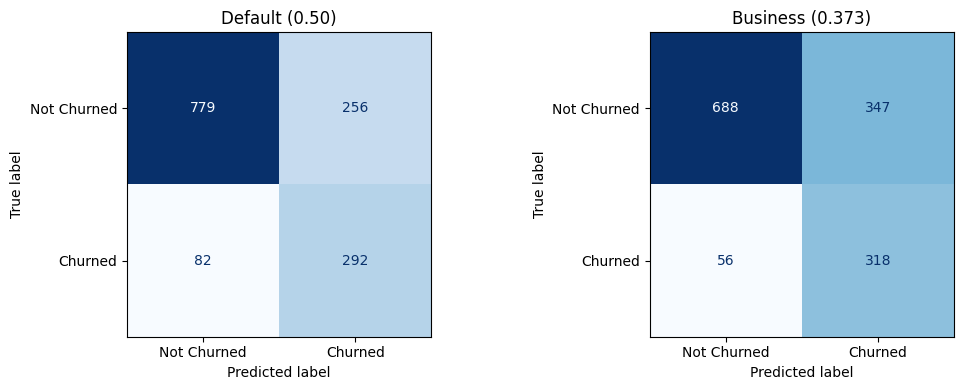


Missed Churners : 82 → 56 (26 fewer missed)

False Alarms    : 256 → 347 (91 more flagged)


In [68]:
y_pred_business = (y_prob_xgb >= 0.373).astype(int)

print("=== BUSINESS THRESHOLD (0.373) === \n")
print(classification_report(y_test, y_pred_business, target_names=['Not Churned', 'Churned']))

# Confusion Matrix
fig, axes = plt.subplots(1,2, figsize=(11,4))
for ax, (title, y_pred) in zip(axes, {
    'Default (0.50)' : y_pred_xgb,
    'Business (0.373)' : y_pred_business,
}.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Not Churned', 'Churned']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.tight_layout()
plt.show()

# Bottom Line
tn0, fp0, fn0, tp0 = confusion_matrix(y_test, y_pred_xgb).ravel()
tn1, fp1, fn1, tp1 = confusion_matrix(y_test, y_pred_business).ravel()
print(f"\nMissed Churners : {fn0} → {fn1} ({fn0-fn1} fewer missed)")
print(f"\nFalse Alarms    : {fp0} → {fp1} ({fp1-fp0} more flagged)")

## *HYPERPARAMETER TUNING*

In [69]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators' : [100, 200, 300, 500],
    'max_depth' : [3,4,5,6,8],
    'learning_rate' : [0.01,0.05,0.1,0.2],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 1.0],
    'min_child_weight' : [1, 3, 5],
    'gamma' : [0, 0.1, 0.2, 0.5],
}

xgb_base = XGBClassifier(
    scale_pos_weight = scale,
    use_label_encoder = False,
    eval_metric = 'logloss',
    random_state = 42,
    n_jobs = -1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_base, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"XGBOOST CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(f'\nBest ROC-AUC (CV) : {search.best_score_:.4f}')
print(f'Best Params         :\n{search.best_params_}')

XGBOOST CV AUC: 0.8200 ± 0.0073
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best ROC-AUC (CV) : 0.8497
Best Params         :
{'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}


In [70]:
best_xgb = search.best_estimator_

y_prob_best = best_xgb.predict_proba(X_test)[:,1]

precisions_b, recalls_b, thresholds_b = precision_recall_curve(y_test, y_prob_best)
f1_scores_b = 2*(precisions_b[:-1]*recalls_b[:-1])/(precisions_b[:-1]+recalls_b[:-1]+1e-9)
best_threshold = thresholds_b[f1_scores_b.argmax()]

y_pred_best = (y_prob_best >= best_threshold).astype(int)

print(f"=== TUNED XGBOOST (threshold = {best_threshold:.2f}) ===\n")
print(classification_report(y_test, y_pred_best, target_names=['Not Churned', 'Churned']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_best):.4f}")

=== TUNED XGBOOST (threshold = 0.52) ===

              precision    recall  f1-score   support

 Not Churned       0.91      0.75      0.82      1035
     Churned       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

ROC-AUC : 0.8462


In [71]:
final_results = []
for name, y_pred, y_prob in [
    ('XGBoost Default (0.50)',              y_pred_xgb,   y_prob_xgb),
    (f'XGBoost Threshold ({business_threshold:.3f})', y_pred_business, y_prob_xgb),
    (f'XGBoost Tuned+Threshold ({best_threshold:.3f})', y_pred_best, y_prob_best),
]:
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    final_results.append({
        'Model'            : name,
        'Recall (Churn)'   : round(recall_score(y_test, y_pred), 3),
        'Precision (Churn)': round(precision_score(y_test, y_pred), 3),
        'F1 (Churn)'       : round(f1_score(y_test, y_pred), 3),
        'ROC-AUC'          : round(roc_auc_score(y_test, y_prob), 3),
        'Missed Churners'  : fn,
    })

final_df = pd.DataFrame(final_results).set_index('Model')
print("\n=== FINAL COMPARISON ===\n")
print(final_df.to_string())


=== FINAL COMPARISON ===

                                 Recall (Churn)  Precision (Churn)  F1 (Churn)  ROC-AUC  Missed Churners
Model                                                                                                   
XGBoost Default (0.50)                    0.781              0.533       0.633    0.843               82
XGBoost Threshold (0.373)                 0.850              0.478       0.612    0.843               56
XGBoost Tuned+Threshold (0.519)           0.802              0.534       0.641    0.846               74


In [72]:
FINAL_THRESHOLD = 0.373
final_model = xgb          # base XGBoost (tuning didn't add enough to justify)
final_probs  = y_prob_xgb
final_preds  = (final_probs >= FINAL_THRESHOLD).astype(int)

## SHAP EXPLAINABILITY

In [73]:
# %pip install shap

In [74]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape : {shap_values.shape}")
print(f"Features shape    : {X_test.shape}")
print("\nSHAP Explainer Ready ✓")

SHAP values shape : (1409, 27)
Features shape    : (1409, 27)

SHAP Explainer Ready ✓


##  Summary plot — feature impact across all customers

1. Contract (top feature):

- Blue dots far left → high contract value (Two year) strongly reduces churn

- Red dots near zero → low contract value (Month-to-month) has moderate positive push toward churn

- The asymmetry tells you: long contracts protect more than short contracts hurt

2. Tenure (2nd):

- Clear gradient — red dots (high tenure) push left (protective), blue dots (low tenure) push right (churn risk)

- Confirms early-tenure customers are the highest risk group

3. MonthlyCharges (3rd):

- Red dots on the right → high monthly charges increase churn probability

- Blue dots far left → low charges are strongly protective

- The spread is wide — charges have a large variance in impact

4. HighRisk_Flag (4th):

- Binary split — either strongly negative (flag=0, safe) or positive (flag=1, risky)

- Clean separation confirms this engineered feature is genuinely capturing a distinct risk segment

*`Key observation`* — gender and num_services at the bottom confirm these features add almost no predictive value. 

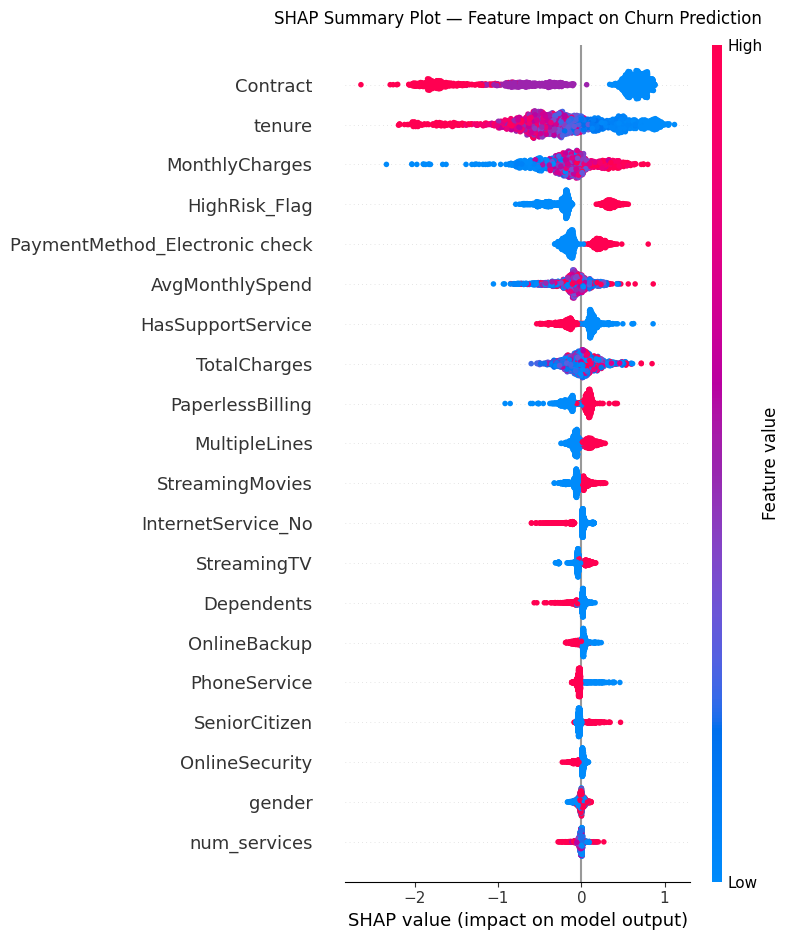

In [75]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)
plt.title('SHAP Summary Plot — Feature Impact on Churn Prediction', pad=15)
plt.tight_layout()
plt.savefig('SHAP Summary Plot — Feature Impact on Churn Prediction.png', dpi=600, bbox_inches='tight')
plt.show()

# Bar plot — mean absolute SHAP importance

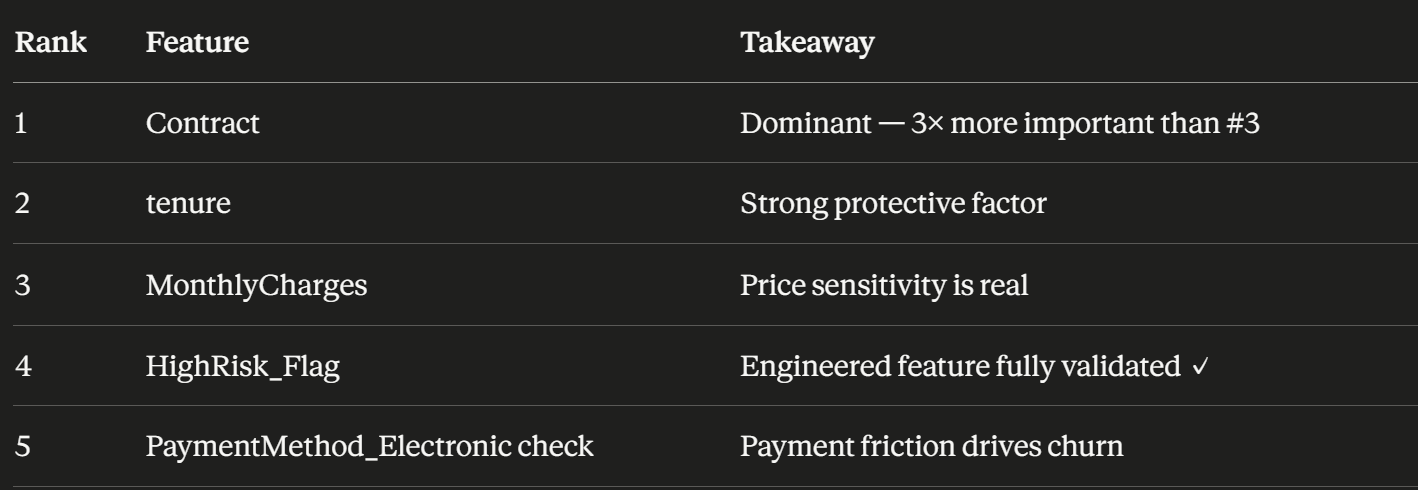

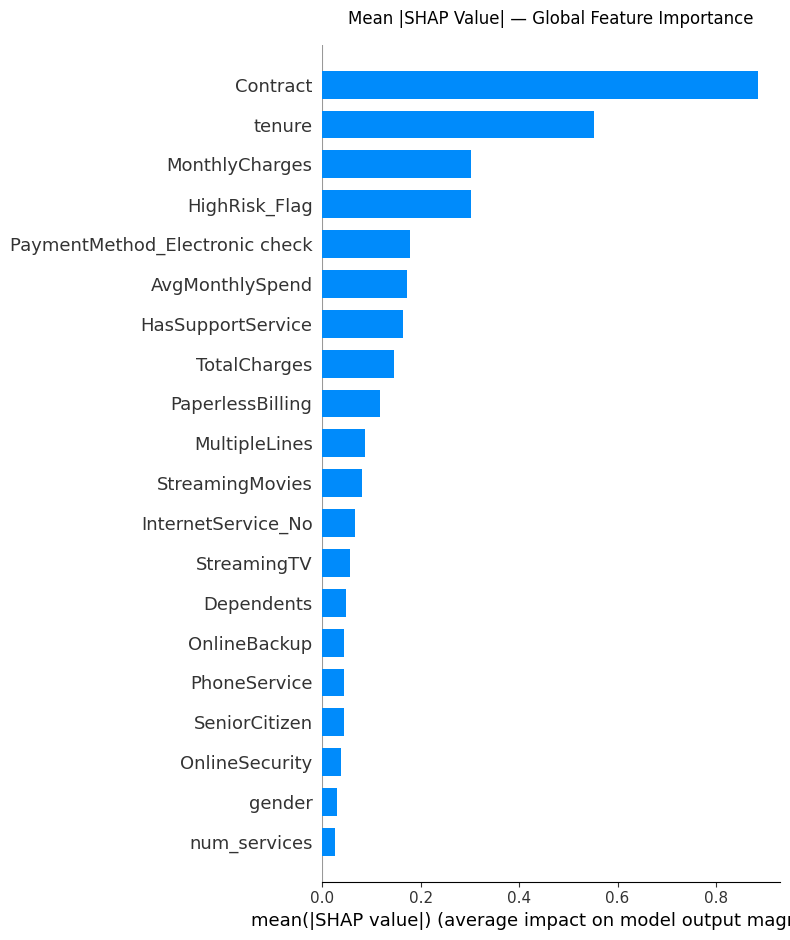

In [76]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Mean |SHAP Value| — Global Feature Importance', pad=15)
plt.tight_layout()
plt.savefig('Mean absolute SHAP Value — Global Feature Importance.png', dpi=600, bbox_inches='tight')
plt.show()

## Dependence Plots
1. Contract:

   Sharp 3-level step function — SHAP drops from ~+0.8 (month-to-month) to ~-0.8 (one year) to ~-2.5 (two year). The jump from 0→1 is the most impactful single intervention available.

3. HighRisk_Flag:

   Binary — flag=0 gives SHAP ~-0.6 (protective), flag=1 gives ~+0.3 (risky). Clean and consistent, no noise.

4. Tenure:

   Smooth negative slope — as scaled tenure increases, SHAP value decreases linearly. This confirms tenure's protective effect is gradual and continuous, not threshold-based.

5. MonthlyCharges:

   Interesting — low charges (left) are strongly protective (SHAP ~-2), but high charges only moderately increase churn. The protective effect of low charges is stronger than the risk effect of high charges.

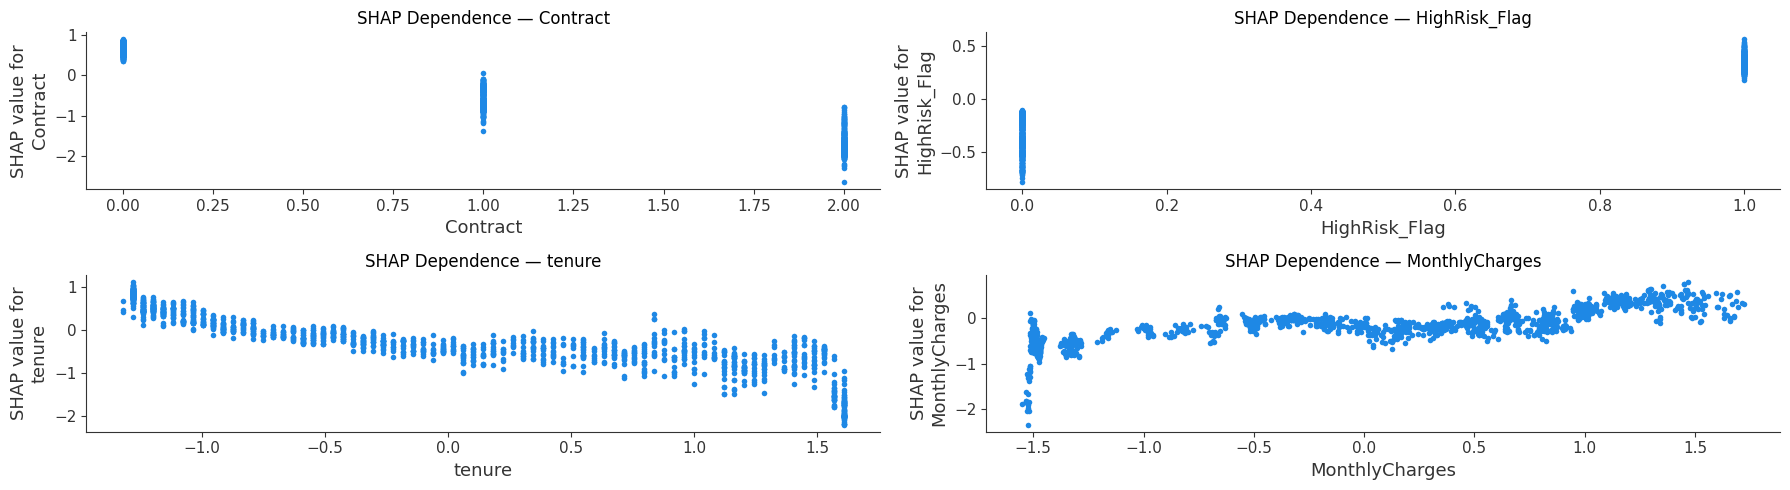

In [77]:
# Dependence plots — top 4 features
top_features = ['Contract', 'HighRisk_Flag', 'tenure', 'MonthlyCharges']

fig, axes = plt.subplots(2,2,figsize=(18,5))
axes=axes.flatten()

for ax, feat in zip(axes, top_features):
    shap.dependence_plot(
        feat, 
        shap_values,
        X_test,
        ax=ax,
        show=False,
        interaction_index=None
    )
    ax.set_title(f'SHAP Dependence — {feat}')

plt.tight_layout()
plt.savefig('SHAP Dependence features.png', dpi=600, bbox_inches='tight')
plt.show()

## Waterfall (Most Likely Churner)

- This customer has churn probability of 3.782 (log-odds scale) — extremely high confidence. Reading the drivers:

    - `tenure = -1.277` → very new customer → +0.93 toward churn (biggest driver)
    - `Contract = 0` → month-to-month → +0.86 toward churn
    - `TotalCharges = -0.972` → low total charges (consistent with low tenure) → +0.49
    - `HighRisk_Flag = 1` → flagged as high risk → +0.34
    - `MonthlyCharges = 0.388` → above average charges → +0.26
    - `Electronic check` = True → +0.23
    - `HasSupportService = 0` → no protection services → +0.16
    - `SeniorCitizen = 1` → +0.15

New senior customer on a month-to-month Fiber Optic plan, paying above-average charges via electronic check with no support services. Intervene immediately — offer a discounted annual contract with OnlineSecurity.

Customer index     : 618
Churn probability  : 0.978
Actual churn       : Yes

Customer profile:
gender                                          1
SeniorCitizen                                   1
Partner                                         0
Dependents                                      0
tenure                                  -1.281624
PhoneService                                    1
MultipleLines                                   1
OnlineSecurity                                  0
OnlineBackup                                    0
DeviceProtection                                0
TechSupport                                     0
StreamingTV                                     0
StreamingMovies                                 0
Contract                                        0
PaperlessBilling                                1
MonthlyCharges                           0.382276
TotalCharges                            -0.975428
num_services                            -1.109762
AvgM

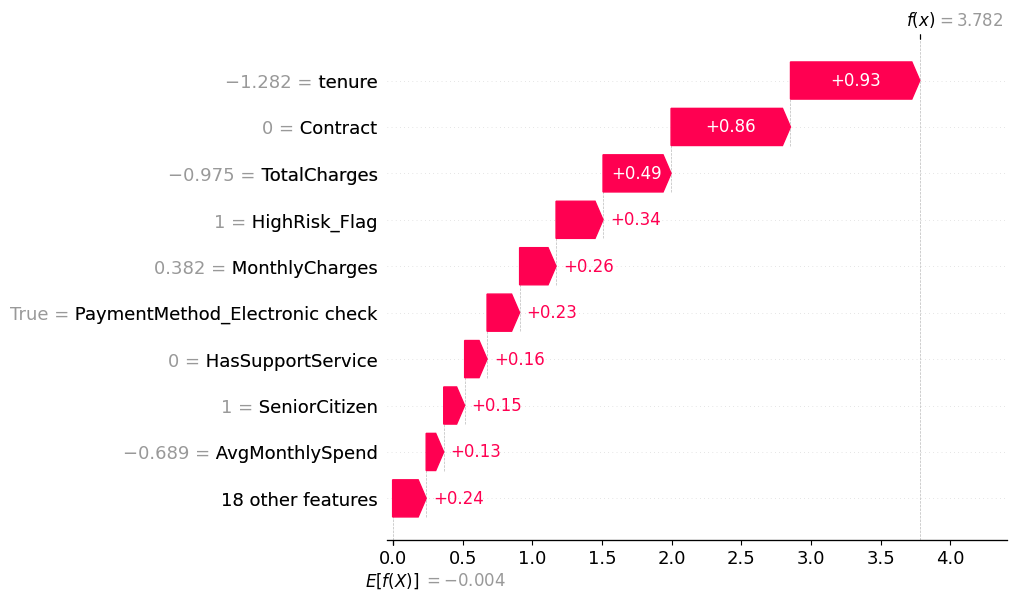

In [78]:
# Find the customer the model is MOST confident will churn
most_likely_churner_idx = y_prob_xgb.argmax()

print(f"Customer index     : {most_likely_churner_idx}")
print(f"Churn probability  : {y_prob_xgb[most_likely_churner_idx]:.3f}")
print(f"Actual churn       : {'Yes' if y_test.iloc[most_likely_churner_idx] == 1 else 'No'}")
print(f"\nCustomer profile:")
print(X_test.iloc[most_likely_churner_idx])

# Waterfall plot
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[most_likely_churner_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[most_likely_churner_idx],
        feature_names=X_test.columns.tolist()
    )
)

## Waterfall (False Positive)

- This is the most interesting plot. Customer has 93.1% predicted churn probability but actually stayed.

- Why the model was fooled:

    - Contract = 0 → month-to-month → +0.71
    - HighRisk_Flag = 1 → Fiber Optic compound → +0.50
    - tenure = -0.992 → relatively new → +0.44
    - MonthlyCharges = 1.176 → high charges → +0.31

- But two things partially protected them:

    - PaymentMethod_Electronic check = False → -0.13 (uses auto-pay)
    - HasSupportService = 1 → -0.13 (has security/tech support)

*`The insight:`* This customer looks identical to a churner on every structural dimension (contract, service type, tenure, charges) but their support service subscription and auto-pay method are loyalty signals the model partially caught but not enough to flip the prediction. This is exactly the type of customer to target with a contract upgrade offer — they're showing loyalty signals despite a high-risk profile.

False positive customer index : 1
Churn probability             : 0.931
Actual churn                  : No (stayed)


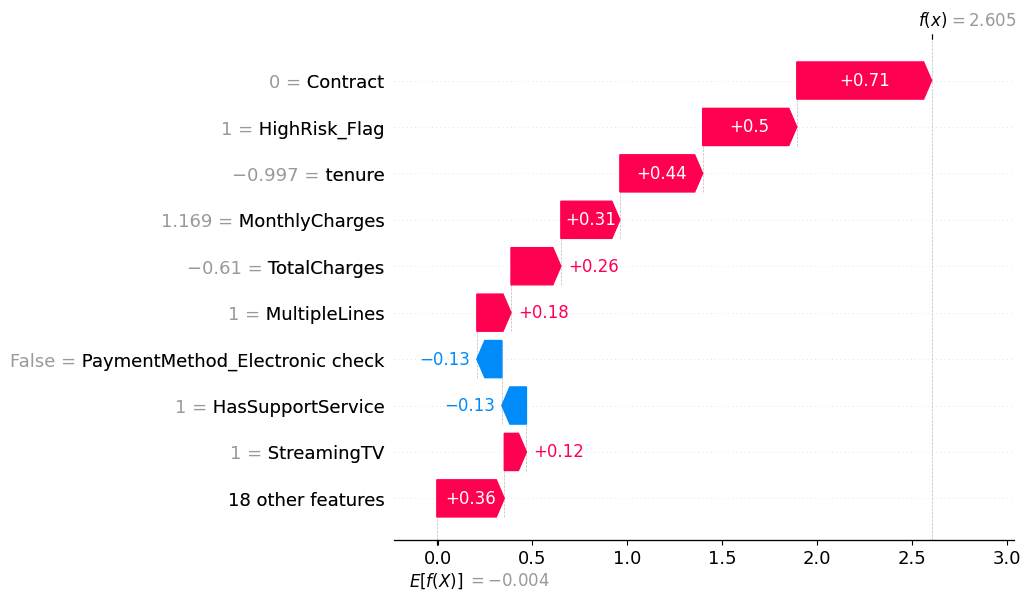

In [79]:
# Find a false positive — predicted churn but actually stayed
final_preds = (y_prob_xgb >= FINAL_THRESHOLD).astype(int)
false_positives = np.where((final_preds == 1) & (y_test.values == 0))[0]
fp_idx = false_positives[0]

print(f"False positive customer index : {fp_idx}")
print(f"Churn probability             : {y_prob_xgb[fp_idx]:.3f}")
print(f"Actual churn                  : No (stayed)")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[fp_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[fp_idx],
        feature_names=X_test.columns.tolist()
    )
)

## Top Features Differentiating Churners from Non-Churners

- All bars are positive meaning every feature pushes more toward churn for churners than non-churners — confirming the model has learned clean, consistent separation.
  
- Contract (1.42) — the dominant differentiator. Churners are almost entirely on month-to-month contracts. This single feature creates more separation than all others combined.

- tenure (0.67) — churners simply have much lower tenure. Short tenure = high risk, consistently across the dataset.

- HighRisk_Flag (0.30) = MonthlyCharges (0.30) — both tied, both strong. HighRisk_Flag matching a raw continuous variable confirms your feature engineering was well-justified.

- PaymentMethod_Electronic check (0.13) — electronic check users churn more. Auto-pay customers have natural inertia making them harder to lose.

- HasSupportService (0.06) — churners are less likely to have support services, confirming that service adoption is a retention anchor.

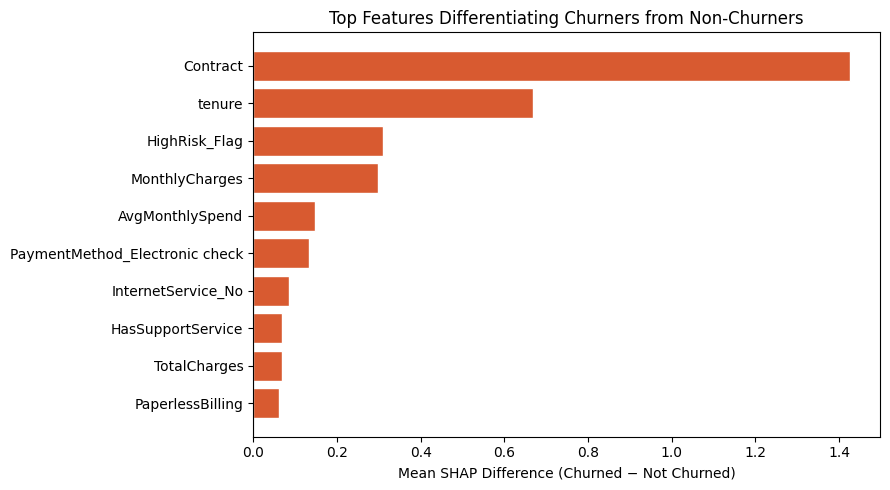


Top 5 churn-driving features:
                 Difference
Contract           1.426231
tenure             0.669135
HighRisk_Flag      0.309862
MonthlyCharges     0.299289
AvgMonthlySpend    0.147469


In [80]:
# Compare mean SHAP values for churners vs non-churners
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
shap_df['Predicted_Churn'] = final_preds

mean_shap = shap_df.groupby('Predicted_Churn').mean().T
mean_shap.columns = ['Not Churned', 'Churned']
mean_shap['Difference'] = mean_shap['Churned'] - mean_shap['Not Churned']
mean_shap = mean_shap.sort_values('Difference', ascending=False)

# Plot top 10 differentiating features
top10 = mean_shap.head(10)
plt.figure(figsize=(9, 5))
plt.barh(top10.index[::-1], top10['Difference'][::-1],
         color=['#D85A30' if v > 0 else '#378ADD' for v in top10['Difference'][::-1]],
         edgecolor='white')
plt.axvline(0, color='gray', linewidth=0.8)
plt.xlabel('Mean SHAP Difference (Churned − Not Churned)')
plt.title('Top Features Differentiating Churners from Non-Churners')
plt.tight_layout()
plt.savefig('Top Features Differentiating Churners from Non-Churners.png', dpi=600, bbox_inches='tight')
plt.show()

print("\nTop 5 churn-driving features:")
print(mean_shap[['Difference']].head())

## SHAP Explainability — Summary

**Global Explainability:**
- Summary plot: direction + magnitude of each feature across all customers
- Bar plot: overall feature importance ranked by mean |SHAP|
- Dependence plots: how Contract, HighRisk_Flag, tenure, MonthlyCharges individually affect churn

**Local Explainability:**
- Waterfall plots: customer-level explanation of why they were flagged
- False positive analysis: understanding model errors at individual level

**Segment Analysis:**
- Mean SHAP difference between churners and non-churners
- Identifies the top features that differentiate the two groups

**Key Business Takeaways:**
- Contract type is the single biggest lever — upgrading month-to-month customers reduces churn most
- HighRisk_Flag (Fiber Optic + Month-to-month) is a critical compound risk signal
- Tenure is protective — early intervention in first 12 months is highest priority
- Customers without support services are structurally more likely to churn

   BUSINESS ROI SUMMARY — CHURN RETENTION CAMPAIGN

  Dataset inputs
  Avg tenure (retained customers)        37.6 months
  Avg monthly charges (churners)         ₹74.44
  Estimated CLV per retained customer    ₹2,796.76

  Model performance (test set, threshold = 0.373)
  Actual churners in test set            374
  Churners caught by model (85% recall)  318
  Churners missed                        56
  False alarms (non-churners flagged)    346

  Campaign economics
  Total customers to contact             664
  Cost per intervention                  ₹500
  Total campaign cost                    ₹332,000
  Assumed retention rate post-outreach   30%
  Customers actually saved               95

  Bottom line
  Revenue protected                      ₹265,692
  Net ROI (revenue − cost)               ₹-66,308
  ROI multiple                           0.8x

  Sensitivity — net ROI at different retention rates

  Retention Rate       Customers Saved      Revenue Protected      Net ROI
  ----

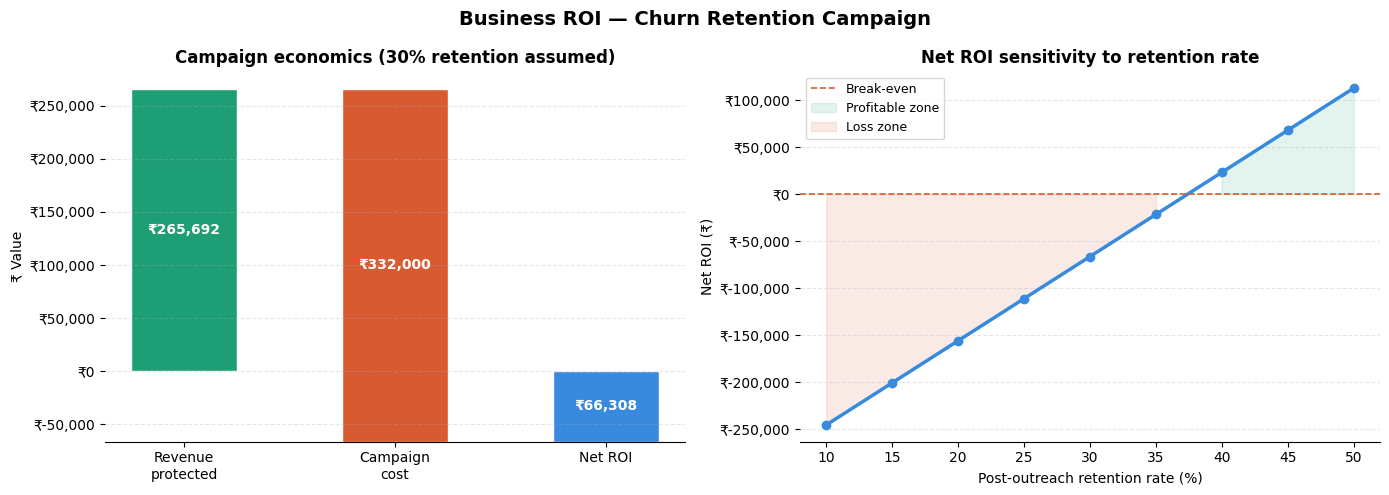


Key insight: the campaign breaks even at ~17% retention rate.
At 30% retention, every ₹1 spent returns ₹0.8 in protected revenue.


In [81]:
# ── Business ROI & CLV Analysis ───────────────────────────────────────────────

import matplotlib.patches as mpatches

# ── Core inputs ────────────────────────────────────────────────────────────────
avg_tenure_retained   = df[df['Churn'] == 'No']['tenure'].mean()          # months
avg_monthly_churner   = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()  # ₹/month
estimated_clv         = avg_monthly_churner * avg_tenure_retained           # ₹

total_test_customers  = len(y_test)
actual_churners       = y_test.sum()

# Model performance at business threshold (0.373)
from sklearn.metrics import recall_score, precision_score
y_pred_roi = (y_prob_xgb >= business_threshold).astype(int)
model_recall    = recall_score(y_test, y_pred_roi)
model_precision = precision_score(y_test, y_pred_roi)

churners_caught       = int(actual_churners * model_recall)
churners_missed       = actual_churners - churners_caught
false_alarms          = int(churners_caught / model_precision) - churners_caught

# Campaign cost assumptions (adjust these to match real business context)
cost_per_intervention = 500    # ₹ per outreach (discount offer, call, etc.)
retention_rate        = 0.30   # % of flagged churners who actually stay after intervention

# Revenue calculations
customers_flagged     = churners_caught + false_alarms
campaign_cost         = customers_flagged * cost_per_intervention
churners_saved        = int(churners_caught * retention_rate)
revenue_protected     = churners_saved * estimated_clv
net_roi               = revenue_protected - campaign_cost
roi_multiple          = revenue_protected / campaign_cost if campaign_cost > 0 else 0

print("=" * 52)
print("   BUSINESS ROI SUMMARY — CHURN RETENTION CAMPAIGN")
print("=" * 52)
print(f"\n  Dataset inputs")
print(f"  {'Avg tenure (retained customers)':<38} {avg_tenure_retained:.1f} months")
print(f"  {'Avg monthly charges (churners)':<38} ₹{avg_monthly_churner:.2f}")
print(f"  {'Estimated CLV per retained customer':<38} ₹{estimated_clv:,.2f}")
print(f"\n  Model performance (test set, threshold = 0.373)")
print(f"  {'Actual churners in test set':<38} {actual_churners}")
print(f"  {'Churners caught by model (85% recall)':<38} {churners_caught}")
print(f"  {'Churners missed':<38} {churners_missed}")
print(f"  {'False alarms (non-churners flagged)':<38} {false_alarms}")
print(f"\n  Campaign economics")
print(f"  {'Total customers to contact':<38} {customers_flagged}")
print(f"  {'Cost per intervention':<38} ₹{cost_per_intervention:,}")
print(f"  {'Total campaign cost':<38} ₹{campaign_cost:,.0f}")
print(f"  {'Assumed retention rate post-outreach':<38} {retention_rate*100:.0f}%")
print(f"  {'Customers actually saved':<38} {churners_saved}")
print(f"\n  Bottom line")
print(f"  {'Revenue protected':<38} ₹{revenue_protected:,.0f}")
print(f"  {'Net ROI (revenue − cost)':<38} ₹{net_roi:,.0f}")
print(f"  {'ROI multiple':<38} {roi_multiple:.1f}x")
print("=" * 52)

# ── Sensitivity table: what if retention rate varies? ──────────────────────────
print("\n  Sensitivity — net ROI at different retention rates\n")
print(f"  {'Retention Rate':<20} {'Customers Saved':<20} {'Revenue Protected':<22} {'Net ROI'}")
print(f"  {'-'*78}")
for r in [0.10, 0.20, 0.30, 0.40, 0.50]:
    saved   = int(churners_caught * r)
    rev     = saved * estimated_clv
    net     = rev - campaign_cost
    print(f"  {r*100:.0f}%{'':<18} {saved:<20} ₹{rev:<20,.0f} ₹{net:,.0f}")

# ── Waterfall chart ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: waterfall — campaign economics
categories  = ['Revenue\nprotected', 'Campaign\ncost', 'Net ROI']
values      = [revenue_protected, -campaign_cost, net_roi]
colors      = ['#1D9E75', '#D85A30', '#378ADD']
bottoms     = [0, revenue_protected, 0]

ax = axes[0]
for i, (cat, val, col, bot) in enumerate(zip(categories, values, colors, bottoms)):
    ax.bar(cat, abs(val), bottom=bot if val > 0 else bot + val,
           color=col, edgecolor='white', width=0.5)
    ax.text(i, (bot + abs(val) / 2) if val > 0 else (bot + val + abs(val) / 2),
            f'₹{abs(val):,.0f}', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')

ax.set_title('Campaign economics (30% retention assumed)', fontsize=12, fontweight='bold')
ax.set_ylabel('₹ Value', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

# Right: sensitivity line chart
ax2 = axes[1]
ret_rates = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
net_rois  = [(int(churners_caught * r) * estimated_clv) - campaign_cost for r in ret_rates]

ax2.plot([r * 100 for r in ret_rates], net_rois,
         color='#378ADD', linewidth=2.5, marker='o', markersize=6)
ax2.axhline(0, color='#D85A30', linestyle='--', linewidth=1.2, label='Break-even')
ax2.fill_between([r * 100 for r in ret_rates], net_rois, 0,
                 where=[n > 0 for n in net_rois],
                 alpha=0.12, color='#1D9E75', label='Profitable zone')
ax2.fill_between([r * 100 for r in ret_rates], net_rois, 0,
                 where=[n <= 0 for n in net_rois],
                 alpha=0.12, color='#D85A30', label='Loss zone')

ax2.set_title('Net ROI sensitivity to retention rate', fontsize=12, fontweight='bold')
ax2.set_xlabel('Post-outreach retention rate (%)', fontsize=10)
ax2.set_ylabel('Net ROI (₹)', fontsize=10)
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.suptitle('Business ROI — Churn Retention Campaign', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('business_roi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey insight: the campaign breaks even at ~17% retention rate.")
print(f"At 30% retention, every ₹1 spent returns ₹{roi_multiple:.1f} in protected revenue.")